In [1]:
# #### AI Gym batched cartpole data generation

# import matplotlib.pylab as plt
# from matplotlib import rc, animation, patches
# rc('animation', html='html5')
# import numpy as np
# import scipy.integrate as integrate
# from scipy.linalg import solve_continuous_are

# import torch
# import numpy as np
# from scipy.linalg import solve_continuous_are

# def wrap(x, m=-np.pi, M=np.pi):
#     """Wraps ``x`` so m <= x <= M; but unlike ``bound()`` which
#     truncates, ``wrap()`` wraps x around the coordinate system defined by m,M.\n
#     For example, m = -180, M = 180 (degrees), x = 360 --> returns 0.

#     Args:
#         x: a scalar
#         m: minimum possible value in range
#         M: maximum possible value in range

#     Returns:
#         x: a scalar, wrapped
#     """
#     diff = M - m
#     while x > M:
#         x = x - diff
#     while x < m:
#         x = x + diff
#     return x


# import torch

# DEFAULT_SWINGUP = {
#     "omega_n_nom": 9.0,   # accel-domain natural freq
#     "zeta": 0.85,
#     "d22_ref_method": "upright",  # 'upright' or 'instant'
#     "tau_max_swing":  8.0, # 10.0,   # cap during swing-up (env global can still be 15)
#     "alpha_q2d": np.pi/7,    # used in q2d mapping (you previously used np.pi/7)
#     "q2d_max": 0.6,
#     "q2d_rate": 3.0,
#     "q2d_tau": 0.12,
#     "energy_scale_factor": 2.0,
#     "taper_cone": 0.6,       # rad
#     "scale_clamp": (0.2, 8.0)
# }


# def get_swingup_params(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                        LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2):
#     """
#     PyTorch version: all parameters can be scalars or tensors of shape (N,)
#     state: shape (4,) for single state or (N, 4) for batch of states
#     Returns: d22_bar, h2_bar, phi2_bar (all shape (N,))
#     """

#     g = 9.81

#     # Ensure state is (N, 4)
#     if state.ndim == 1:
#         state = state.unsqueeze(0)   # (1, 4)
#     theta1, theta2, theta1_dot, theta2_dot = state.T  # each shape (N,)

#     # Convert params to tensors
#     device = state.device
#     dtype = state.dtype
#     def ensure_tensor(x):
#         return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

#     LINK_LENGTH_1 = ensure_tensor(LINK_LENGTH_1)
#     LINK_LENGTH_2 = ensure_tensor(LINK_LENGTH_2)
#     LINK_MASS_1 = ensure_tensor(LINK_MASS_1)
#     LINK_MASS_2 = ensure_tensor(LINK_MASS_2)
#     LINK_COM_POS_1 = ensure_tensor(LINK_COM_POS_1)
#     LINK_COM_POS_2 = ensure_tensor(LINK_COM_POS_2)
#     LINK_MOI1 = ensure_tensor(LINK_MOI1)
#     LINK_MOI2 = ensure_tensor(LINK_MOI2)

#     # Broadcast to match batch size
#     N = state.shape[0]
#     def expand(x): return x.expand(N) if x.ndim == 0 else x
#     LINK_LENGTH_1 = expand(LINK_LENGTH_1)
#     LINK_LENGTH_2 = expand(LINK_LENGTH_2)
#     LINK_MASS_1 = expand(LINK_MASS_1)
#     LINK_MASS_2 = expand(LINK_MASS_2)
#     LINK_COM_POS_1 = expand(LINK_COM_POS_1)
#     LINK_COM_POS_2 = expand(LINK_COM_POS_2)
#     LINK_MOI1 = expand(LINK_MOI1)
#     LINK_MOI2 = expand(LINK_MOI2)

#     # Dynamics terms
#     d11 = (LINK_MASS_1 * LINK_COM_POS_1**2 +
#            LINK_MASS_2 * (LINK_LENGTH_1**2 + LINK_COM_POS_2**2 +
#                           2 * LINK_LENGTH_1 * LINK_COM_POS_2 * torch.cos(theta2)) +
#            LINK_MOI1 + LINK_MOI2)

#     d22 = LINK_MASS_2 * LINK_COM_POS_2**2 + LINK_MOI2

#     d12 = LINK_MASS_2 * (LINK_COM_POS_2**2 +
#                          LINK_LENGTH_1 * LINK_COM_POS_2 * torch.cos(theta2)) + LINK_MOI2

#     h1 = (-LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 *
#           torch.sin(theta2) * theta2_dot**2 -
#           2 * LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 *
#           torch.sin(theta2) * theta1_dot * theta2_dot)

#     h2 = LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 * torch.sin(theta2) * theta1_dot**2

#     phi1 = ((LINK_MASS_1 * LINK_COM_POS_1 + LINK_MASS_2 * LINK_LENGTH_1) *
#             g * torch.cos(theta1 - torch.pi / 2.0) +
#             LINK_MASS_2 * g * LINK_COM_POS_2 *
#             torch.cos(theta1 + theta2 - torch.pi / 2.0))

#     phi2 = (LINK_MASS_2 * LINK_COM_POS_2 * g *
#             torch.cos(theta1 + theta2 - torch.pi / 2.0))

#     # Reduced terms
#     d22_bar = d22 - d12**2 / d11
#     h2_bar = h2 - d12 / d11 * h1
#     phi2_bar = phi2 - d12 / d11 * phi1

#     return d22_bar, h2_bar, phi2_bar


# import numpy as np
# from scipy.linalg import solve_continuous_are

# def LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                    LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2):
#     """
#     Vectorized LQR controller gain computation.
#     Parameters can be scalars or arrays of shape (N,)
#     Returns: K (N, 4)
#     """

#     g = 9.81
#     goal_state = np.array([np.pi, 0.0, 0.0, 0.0])  # Upright position

#     # Make everything arrays
#     LINK_LENGTH_1 = np.atleast_1d(LINK_LENGTH_1)
#     LINK_LENGTH_2 = np.atleast_1d(LINK_LENGTH_2)
#     LINK_MASS_1   = np.atleast_1d(LINK_MASS_1)
#     LINK_MASS_2   = np.atleast_1d(LINK_MASS_2)
#     LINK_COM_POS_1 = np.atleast_1d(LINK_COM_POS_1)
#     LINK_COM_POS_2 = np.atleast_1d(LINK_COM_POS_2)
#     LINK_MOI1     = np.atleast_1d(LINK_MOI1)
#     LINK_MOI2     = np.atleast_1d(LINK_MOI2)

#     N = max(map(len, [LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                       LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2]))

#     # Broadcast all params to same shape (N,)
#     (LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#      LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2) = np.broadcast_arrays(
#         LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#         LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, np.zeros(N)
#     )[:-1]

#     Ks = []
#     for i in range(N):
#         # Build M and dtau_ds for system i
#         M = np.array([
#             [LINK_MASS_1[i] * LINK_COM_POS_1[i]**2 +
#              LINK_MASS_2[i] * (LINK_LENGTH_1[i]**2 + LINK_COM_POS_2[i]**2 +
#                                2 * LINK_LENGTH_1[i] * LINK_COM_POS_2[i] * np.cos(goal_state[1])) +
#              LINK_MOI1[i] + LINK_MOI2[i],
#              LINK_MASS_2[i] * (LINK_COM_POS_2[i]**2 + LINK_LENGTH_1[i] * LINK_COM_POS_2[i] * np.cos(goal_state[1])) + LINK_MOI2[i]],
#             [LINK_MASS_2[i] * (LINK_COM_POS_2[i]**2 + LINK_LENGTH_1[i] * LINK_COM_POS_2[i] * np.cos(goal_state[1])) + LINK_MOI2[i],
#              LINK_MASS_2[i] * LINK_COM_POS_2[i]**2 + LINK_MOI2[i]]
#         ])

#         dtau_ds = np.array([
#             [g * (LINK_MASS_1[i] * LINK_COM_POS_1[i] + LINK_MASS_2[i] * LINK_LENGTH_1[i] + LINK_MASS_2[i] * LINK_COM_POS_2[i]),
#              LINK_MASS_2[i] * LINK_COM_POS_2[i] * g],
#             [LINK_MASS_2[i] * LINK_COM_POS_2[i] * g,
#              LINK_MASS_2[i] * LINK_COM_POS_2[i] * g]
#         ])

#         # Build A, B
#         A = np.block([
#             [np.zeros((2, 2)), np.eye(2)],
#             [np.linalg.inv(M) @ dtau_ds, np.zeros((2, 2))]
#         ])
#         B = np.block([
#             [np.zeros((2, 1))],
#             [np.linalg.inv(M) @ np.array([[0], [1]])]
#         ])

#         # LQR weights
#         Q = np.eye(4) * 1000
#         R = np.eye(1) * 100

#         # Solve CARE and get K
#         P = solve_continuous_are(A, B, Q, R)
#         K = np.linalg.inv(R) @ B.T @ P
#         Ks.append(K.flatten())

#     return np.stack(Ks, axis=0)  # (N, 4)


# import torch

# def _total_energy(theta1, theta2, d1, d2,
#                   m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
#     """
#     Vectorized total energy for acrobot (PyTorch version).
    
#     Parameters:
#         theta1, theta2, d1, d2 : float or tensor, shape (N,) or scalar
#         m1, m2, l1, lc1, lc2, I1, I2 : float or tensor, shape (N,) or scalar
#         g : gravity (float)
    
#     Returns:
#         Total energy (N,) tensor if inputs are batched, else scalar tensor.
#     """

#     # Convert everything to tensors on the same device/dtype
#     device = (theta1.device if isinstance(theta1, torch.Tensor)
#               else torch.device("cpu"))
#     dtype = (theta1.dtype if isinstance(theta1, torch.Tensor)
#              else torch.float32)

#     def ensure_tensor(x):
#         return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

#     theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = map(
#         ensure_tensor, (theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2)
#     )

#     # Broadcast to common shape
#     theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = torch.broadcast_tensors(
#         theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2
#     )

#     # Kinetic energy
#     c2 = torch.cos(theta2)
#     D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
#     D12 = m2*(lc2**2 + l1*lc2*c2) + I2
#     D22 = m2*lc2**2 + I2

#     dq = torch.stack([d1, d2], dim=-1)  # (N, 2)
#     D = torch.stack([
#         torch.stack([D11, D12], dim=-1),
#         torch.stack([D12, D22], dim=-1)
#     ], dim=-2)  # (N, 2, 2)

#     KE = 0.5 * torch.einsum("...i,...ij,...j->...", dq, D, dq)

#     # Potential energy
#     y1 = lc1 * torch.cos(theta1 - torch.pi/2.0)
#     y_tip = l1 * torch.cos(theta1 - torch.pi/2.0)
#     y2 = y_tip + lc2 * torch.cos(theta1 + theta2 - torch.pi/2.0)

#     PE = m1 * g * y1 + m2 * g * y2

#     return KE + PE

# import torch

# def _compute_d22_ref_upright(LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
#                              LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2,
#                              eps: float = 1e-6):
#     """
#     Compute d22_bar at upright (theta2 = 0).
#     Works with scalars or batched tensors in PyTorch.

#     Returns:
#         d22_ref (tensor): shape () if scalars, or (N,) if batched
#     """
#     # Get device/dtype from first arg
#     device = (LINK_LENGTH_1.device if isinstance(LINK_LENGTH_1, torch.Tensor)
#               else torch.device("cpu"))
#     dtype = (LINK_LENGTH_1.dtype if isinstance(LINK_LENGTH_1, torch.Tensor)
#              else torch.float32)

#     def ensure_tensor(x):
#         return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

#     l1, lc1, lc2, m1, m2, I1, I2 = map(
#         ensure_tensor, (LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
#                         LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2)
#     )

#     # Broadcast to common shape
#     l1, lc1, lc2, m1, m2, I1, I2 = torch.broadcast_tensors(l1, lc1, lc2, m1, m2, I1, I2)

#     # cos(theta2 = 0) = 1
#     c2_u = 1.0

#     d11_u = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2_u) + I1 + I2
#     d12_u = m2*(lc2**2 + l1*lc2*c2_u) + I2
#     d22_u = m2*lc2**2 + I2

#     d22_ref = d22_u - d12_u**2 / d11_u
#     d22_ref = torch.clamp(d22_ref, min=eps)  # enforce >= eps

#     return d22_ref


# import torch

# # def swingup_lqr_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
# #                            LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2,
# #                            params=DEFAULT_SWINGUP):
# #     """
# #     Vectorized PyTorch version.
# #     state: (...,4) tensor [theta1, theta2, theta1_dot, theta2_dot]
# #     Returns: (f, mode) where f and mode are tensors.
# #     """
# #     device, dtype = state.device, state.dtype
# #     theta1, theta2, theta1_dot, theta2_dot = state.unbind(-1)

# #     g = torch.tensor(9.81, device=device, dtype=dtype)
# #     goal_state = torch.tensor([torch.pi, 0.0, 0.0, 0.0], device=device, dtype=dtype)

# #     # --- check switching condition ---
# #     cond = (
# #         torch.abs(wrap(theta1 - goal_state[0])) < 0.4
# #     ) & (
# #         torch.abs(wrap(theta2 - goal_state[1])) < 0.7
# #     ) & (
# #         torch.abs(theta1_dot - goal_state[2]) < 0.8
# #     ) & (
# #         torch.abs(theta2_dot - goal_state[3]) < 0.8
# #     )

# #     f = torch.zeros_like(theta1)
# #     mode = torch.zeros_like(theta1, dtype=torch.long)

# #     if cond.any():
# #         K_lqr = LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2,
# #                                LINK_MASS_1, LINK_MASS_2,
# #                                LINK_COM_POS_1, LINK_COM_POS_2,
# #                                LINK_MOI1, LINK_MOI2)
# #         err = torch.stack([wrap(theta1 - torch.pi),
# #                            wrap(theta2),
# #                            theta1_dot, theta2_dot], dim=-1)
# #         f[cond] = -(K_lqr @ err[..., None]).squeeze(-1)[cond]
# #         mode[cond] = 1

# #     # swing-up branch for others
# #     not_cond = ~cond
# #     if not_cond.any():
# #         # parameters
# #         omega_n_nom = params["omega_n_nom"]
# #         zeta = params["zeta"]
# #         d22_ref_method = params["d22_ref_method"]
# #         tau_max_swing = params["tau_max_swing"]
# #         alpha_q2d = params["alpha_q2d"]
# #         q2d_max = params["q2d_max"]
# #         q2d_rate = params["q2d_rate"]
# #         q2d_tau = params["q2d_tau"]
# #         energy_scale_factor = params["energy_scale_factor"]
# #         taper_cone = params["taper_cone"]
# #         scale_min, scale_max = params["scale_clamp"]

# #         d22_bar, h2_bar, phi2_bar = get_swingup_params(
# #             state, LINK_LENGTH_1, LINK_LENGTH_2,
# #             LINK_MASS_1, LINK_MASS_2,
# #             LINK_COM_POS_1, LINK_COM_POS_2,
# #             LINK_MOI1, LINK_MOI2
# #         )

# #         if d22_ref_method == "upright":
# #             d22_ref = _compute_d22_ref_upright(
# #                 LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
# #                 LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2
# #             )
# #         else:
# #             d22_ref = torch.clamp(d22_bar, min=1e-6)

# #         k_p_acc = omega_n_nom**2
# #         k_d_acc = 2.0 * zeta * omega_n_nom

# #         scale = 1.0 / torch.clamp(d22_ref, min=1e-6)
# #         scale = torch.clamp(scale, min=scale_min, max=scale_max)
# #         kp = k_p_acc * scale
# #         kd = k_d_acc * scale

# #         # --- energy scheduling ---
# #         E = _total_energy(theta1, theta2, theta1_dot, theta2_dot,
# #                           LINK_MASS_1, LINK_MASS_2,
# #                           LINK_LENGTH_1, LINK_COM_POS_1,
# #                           LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
# #         E_target = _total_energy(torch.pi, 0.0, 0.0, 0.0,
# #                                  LINK_MASS_1, LINK_MASS_2,
# #                                  LINK_LENGTH_1, LINK_COM_POS_1,
# #                                  LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
# #         E_err = E - E_target
# #         E_scale = torch.maximum(torch.abs(E_target), torch.tensor(1.0, device=device)) * energy_scale_factor
# #         s_energy = torch.clamp(torch.abs(E_err) / (E_scale + 1e-8), 0.0, 1.0)

# #         kp_eff = (1.0 - s_energy) * (0.4 * kp) + s_energy * kp
# #         kd_eff = (1.0 - s_energy) * (1.6 * kd) + s_energy * kd

# #         # --- desired q2d ---
# #         q2d_raw = alpha_q2d * torch.atan(theta1_dot)
# #         q2d_raw = torch.clamp(q2d_raw, -q2d_max, q2d_max)

# #         if not hasattr(swingup_lqr_controller, "q2d_prev"):
# #             swingup_lqr_controller.q2d_prev = torch.zeros_like(q2d_raw)

# #         dq = torch.clamp(q2d_raw - swingup_lqr_controller.q2d_prev,
# #                          -q2d_rate * 0.05, q2d_rate * 0.05)
# #         q2d_rl = swingup_lqr_controller.q2d_prev + dq
# #         a_q = 0.05 / (q2d_tau + 0.05)
# #         q2d = (1.0 - a_q) * swingup_lqr_controller.q2d_prev + a_q * q2d_rl
# #         swingup_lqr_controller.q2d_prev = q2d.detach()

# #         err_q2 = wrap(q2d - theta2)
# #         v2 = kp_eff * err_q2 - kd_eff * theta2_dot

# #         th1_err_abs = torch.abs(wrap(theta1 - torch.pi))
# #         taper = torch.where(th1_err_abs < taper_cone,
# #                             0.25 + 0.75 * (th1_err_abs / taper_cone),
# #                             torch.ones_like(th1_err_abs))
# #         v2 = v2 * taper

# #         f_sw = d22_bar * v2 + h2_bar + phi2_bar
# #         f_sw = torch.clamp(f_sw, -tau_max_swing, tau_max_swing)
# #         f[not_cond] = f_sw[not_cond]
# #         mode[not_cond] = 0

# #     return f, mode


# def swingup_lqr_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                            LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2,
#                            q2d_prev=None, params=DEFAULT_SWINGUP):
#     """
#     Vectorized PyTorch swing-up/LQR controller with per-batch q2d_prev.
    
#     state: (batch,4) tensor [theta1, theta2, theta1_dot, theta2_dot]
#     q2d_prev: (batch,) tensor of previous q2d values for smoothing
#               or None to initialize as zeros
              
#     Returns:
#         f: (batch,) tensor of torques
#         mode: (batch,) tensor of 0 (swing-up) or 1 (LQR)
#         q2d_new: (batch,) tensor of updated q2d_prev
#     """
#     device, dtype = state.device, state.dtype
#     theta1, theta2, theta1_dot, theta2_dot = state.unbind(-1)

#     batch_size = state.shape[0]

#     if q2d_prev is None:
#         q2d_prev = torch.zeros(batch_size, device=device, dtype=dtype)

#     g = torch.tensor(9.81, device=device, dtype=dtype)
#     goal_state = torch.tensor([torch.pi, 0.0, 0.0, 0.0], device=device, dtype=dtype)

#     # --- switching condition for LQR ---
#     cond_lqr = (
#         torch.abs(wrap(theta1 - goal_state[0])) < 0.4
#     ) & (
#         torch.abs(wrap(theta2 - goal_state[1])) < 0.7
#     ) & (
#         torch.abs(theta1_dot - goal_state[2]) < 0.8
#     ) & (
#         torch.abs(theta2_dot - goal_state[3]) < 0.8
#     )

#     f = torch.zeros(batch_size, device=device, dtype=dtype)
#     mode = torch.zeros(batch_size, device=device, dtype=torch.long)

#     # --- LQR branch ---
#     if cond_lqr.any():
#         K_lqr = LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2,
#                                LINK_MASS_1, LINK_MASS_2,
#                                LINK_COM_POS_1, LINK_COM_POS_2,
#                                LINK_MOI1, LINK_MOI2)
#         err = torch.stack([wrap(theta1 - torch.pi),
#                            wrap(theta2),
#                            theta1_dot, theta2_dot], dim=-1)
#         f[cond_lqr] = -(K_lqr @ err[cond_lqr].unsqueeze(-1)).squeeze(-1)
#         mode[cond_lqr] = 1

#     # --- swing-up branch ---
#     not_lqr = ~cond_lqr
#     if not_lqr.any():
#         # unpack params
#         omega_n_nom = params["omega_n_nom"]
#         zeta = params["zeta"]
#         d22_ref_method = params["d22_ref_method"]
#         tau_max_swing = params["tau_max_swing"]
#         alpha_q2d = params["alpha_q2d"]
#         q2d_max = params["q2d_max"]
#         q2d_rate = params["q2d_rate"]
#         q2d_tau = params["q2d_tau"]
#         energy_scale_factor = params["energy_scale_factor"]
#         taper_cone = params["taper_cone"]
#         scale_min, scale_max = params["scale_clamp"]

#         d22_bar, h2_bar, phi2_bar = get_swingup_params(
#             state[not_lqr], LINK_LENGTH_1, LINK_LENGTH_2,
#             LINK_MASS_1, LINK_MASS_2,
#             LINK_COM_POS_1, LINK_COM_POS_2,
#             LINK_MOI1, LINK_MOI2
#         )

#         if d22_ref_method == "upright":
#             d22_ref = _compute_d22_ref_upright(
#                 LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
#                 LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2
#             )
#         else:
#             d22_ref = torch.clamp(d22_bar, min=1e-6)

#         k_p_acc = omega_n_nom**2
#         k_d_acc = 2.0 * zeta * omega_n_nom
#         scale = 1.0 / torch.clamp(d22_ref, min=1e-6)
#         scale = torch.clamp(scale, min=scale_min, max=scale_max)
#         kp = k_p_acc * scale
#         kd = k_d_acc * scale

#         # energy shaping
#         E = _total_energy(theta1[not_lqr], theta2[not_lqr], theta1_dot[not_lqr], theta2_dot[not_lqr],
#                           LINK_MASS_1, LINK_MASS_2,
#                           LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
#                           LINK_MOI1, LINK_MOI2)
#         E_target = _total_energy(torch.pi, 0.0, 0.0, 0.0,
#                                  LINK_MASS_1, LINK_MASS_2,
#                                  LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
#                                  LINK_MOI1, LINK_MOI2)
#         E_err = E - E_target
#         E_scale = torch.maximum(torch.abs(E_target), torch.tensor(1.0, device=device)) * energy_scale_factor
#         s_energy = torch.clamp(torch.abs(E_err) / (E_scale + 1e-8), 0.0, 1.0)
#         kp_eff = (1.0 - s_energy) * (0.4 * kp) + s_energy * kp
#         kd_eff = (1.0 - s_energy) * (1.6 * kd) + s_energy * kd

#         # q2d smoothing
#         q2d_raw = alpha_q2d * torch.atan(theta1_dot[not_lqr])
#         q2d_raw = torch.clamp(q2d_raw, -q2d_max, q2d_max)

#         dq = torch.clamp(q2d_raw - q2d_prev[not_lqr],
#                          -q2d_rate * 0.05, q2d_rate * 0.05)
#         q2d_rl = q2d_prev[not_lqr] + dq
#         a_q = 0.05 / (q2d_tau + 0.05)
#         q2d_new = q2d_prev.clone()
#         q2d_new[not_lqr] = (1.0 - a_q) * q2d_prev[not_lqr] + a_q * q2d_rl

#         err_q2 = wrap(q2d_new[not_lqr] - theta2[not_lqr])
#         v2 = kp_eff * err_q2 - kd_eff * theta2_dot[not_lqr]

#         th1_err_abs = torch.abs(wrap(theta1[not_lqr] - torch.pi))
#         taper = torch.where(th1_err_abs < taper_cone,
#                             0.25 + 0.75 * (th1_err_abs / taper_cone),
#                             torch.ones_like(th1_err_abs))
#         v2 = v2 * taper

#         f_su = d22_bar * v2 + h2_bar + phi2_bar
#         f[not_lqr] = torch.clamp(f_su, -tau_max_swing, tau_max_swing)
#         mode[not_lqr] = 0

#         return f, mode, q2d_new

#     return f, mode, q2d_prev

# # def swingup_lqr_controller2(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
# #                             LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, mode,
# #                             params=DEFAULT_SWINGUP):
# #     """
# #     Vectorized PyTorch version with hysteresis switching.
# #     state: (...,4) tensor
# #     mode: (...,) tensor of ints
# #     Returns: (f, mode)
# #     """
# #     theta1, theta2, theta1_dot, theta2_dot = state.unbind(-1)
# #     goal_state = torch.tensor([torch.pi, 0.0, 0.0, 0.0], device=state.device, dtype=state.dtype)

# #     eps_in = (0.4, 0.7, 0.8, 0.8)
# #     eps_out = (0.7, 1.1, 1.3, 1.3)

# #     er_theta1 = torch.abs(wrap(theta1 - goal_state[0]))
# #     er_theta2 = torch.abs(wrap(theta2 - goal_state[1]))
# #     er_theta1_dot = torch.abs(theta1_dot - goal_state[2])
# #     er_theta2_dot = torch.abs(theta2_dot - goal_state[3])

# #     in_mask = (er_theta1 < eps_in[0]) & (er_theta2 < eps_in[1]) & \
# #               (er_theta1_dot < eps_in[2]) & (er_theta2_dot < eps_in[3])
# #     out_mask = (er_theta1 > eps_out[0]) | (er_theta2 > eps_out[1]) | \
# #                (er_theta1_dot > eps_out[2]) | (er_theta2_dot > eps_out[3])

# #     mode_next = mode.clone()
# #     mode_next[(mode == 0) & in_mask] = 1
# #     mode_next[(mode == 1) & out_mask] = 0

# #     f = torch.zeros_like(theta1)

# #     mask_lqr = (mode_next == 1)
# #     if mask_lqr.any():
# #         K_lqr = LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2,
# #                                LINK_MASS_1, LINK_MASS_2,
# #                                LINK_COM_POS_1, LINK_COM_POS_2,
# #                                LINK_MOI1, LINK_MOI2)
# #         err = torch.stack([wrap(theta1 - torch.pi),
# #                            wrap(theta2),
# #                            theta1_dot, theta2_dot], dim=-1)
# #         f[mask_lqr] = -(K_lqr @ err[..., None]).squeeze(-1)[mask_lqr]

# #     mask_su = (mode_next == 0)
# #     if mask_su.any():
# #         f_su, _ = swingup_lqr_controller(state, LINK_LENGTH_1, LINK_LENGTH_2,
# #                                          LINK_MASS_1, LINK_MASS_2,
# #                                          LINK_COM_POS_1, LINK_COM_POS_2,
# #                                          LINK_MOI1, LINK_MOI2, params)
# #         f[mask_su] = f_su[mask_su]

# #     return f, mode_next


# def swingup_lqr_controller2(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                             LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2,
#                             mode, q2d_prev=None, params=DEFAULT_SWINGUP):
#     """
#     Vectorized PyTorch swing-up/LQR controller with hysteresis and per-batch q2d_prev.
    
#     state: (batch,4) tensor [theta1, theta2, theta1_dot, theta2_dot]
#     mode: (batch,) tensor of ints (0=swingup, 1=LQR)
#     q2d_prev: (batch,) tensor of previous q2d for smoothing
    
#     Returns:
#         f: (batch,) tensor of torques
#         mode_next: (batch,) tensor of updated modes
#         q2d_new: (batch,) tensor of updated q2d_prev
#     """
#     device, dtype = state.device, state.dtype
#     batch_size = state.shape[0]
    
#     if q2d_prev is None:
#         q2d_prev = torch.zeros(batch_size, device=device, dtype=dtype)
    
#     theta1, theta2, theta1_dot, theta2_dot = state.unbind(-1)
#     goal_state = torch.tensor([torch.pi, 0.0, 0.0, 0.0], device=device, dtype=dtype)
    
#     eps_in = (0.4, 0.7, 0.8, 0.8)
#     eps_out = (0.7, 1.1, 1.3, 1.3)
    
#     er_theta1 = torch.abs(wrap(theta1 - goal_state[0]))
#     er_theta2 = torch.abs(wrap(theta2 - goal_state[1]))
#     er_theta1_dot = torch.abs(theta1_dot - goal_state[2])
#     er_theta2_dot = torch.abs(theta2_dot - goal_state[3])
    
#     # --- hysteresis switching ---
#     in_mask = (er_theta1 < eps_in[0]) & (er_theta2 < eps_in[1]) & \
#               (er_theta1_dot < eps_in[2]) & (er_theta2_dot < eps_in[3])
#     out_mask = (er_theta1 > eps_out[0]) | (er_theta2 > eps_out[1]) | \
#                (er_theta1_dot > eps_out[2]) | (er_theta2_dot > eps_out[3])
    
#     mode_next = mode.clone()
#     mode_next[(mode == 0) & in_mask] = 1
#     mode_next[(mode == 1) & out_mask] = 0
    
#     f = torch.zeros(batch_size, device=device, dtype=dtype)
    
#     # --- LQR branch ---
#     mask_lqr = (mode_next == 1)
#     if mask_lqr.any():
#         K_lqr = LQR_controller(state[mask_lqr], LINK_LENGTH_1, LINK_LENGTH_2,
#                                LINK_MASS_1, LINK_MASS_2,
#                                LINK_COM_POS_1, LINK_COM_POS_2,
#                                LINK_MOI1, LINK_MOI2)
#         err = torch.stack([wrap(theta1[mask_lqr] - torch.pi),
#                            wrap(theta2[mask_lqr]),
#                            theta1_dot[mask_lqr],
#                            theta2_dot[mask_lqr]], dim=-1)
#         f[mask_lqr] = -(K_lqr @ err.unsqueeze(-1)).squeeze(-1)
    
#     # --- swing-up branch ---
#     mask_su = (mode_next == 0)
#     if mask_su.any():
#         f_su, _, q2d_new_su = swingup_lqr_controller(
#             state[mask_su], LINK_LENGTH_1, LINK_LENGTH_2,
#             LINK_MASS_1, LINK_MASS_2,
#             LINK_COM_POS_1, LINK_COM_POS_2,
#             LINK_MOI1, LINK_MOI2,
#             q2d_prev=q2d_prev[mask_su],
#             params=params
#         )
#         f[mask_su] = f_su
#         q2d_prev = q2d_prev.clone()
#         q2d_prev[mask_su] = q2d_new_su
    
#     return f, mode_next, q2d_prev



# import torch

# def wrap(x, low=-torch.pi, high=torch.pi):
#     """Wrap angle x to [low, high). Works for tensors."""
#     return ((x - low) % (high - low)) + low

# def bound(x, low, high):
#     """Clamp tensor between low and high."""
#     return torch.clamp(x, low, high)

# def rk4_batch(derivs, y0, dt):
#     """
#     Batched Runge-Kutta 4 integrator.
    
#     y0: (batch, state_dim)
#     derivs: function(y) -> dy (batch, state_dim)
#     dt: float
#     """
#     k1 = derivs(y0)
#     k2 = derivs(y0 + dt/2 * k1)
#     k3 = derivs(y0 + dt/2 * k2)
#     k4 = derivs(y0 + dt * k3)
#     return y0 + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

# def dsdt_batch(s_augmented, params):
#     """
#     Batched dynamics function.
#     s_augmented: (batch, 5) -> [theta1, theta2, dtheta1, dtheta2, torque]
#     params: dict with LINK_MASS_1, LINK_MASS_2, LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, 'book_or_nips'
#     Returns: (batch,4) tensor [dtheta1, dtheta2, ddtheta1, ddtheta2]
#     """
#     m1 = params['LINK_MASS_1']
#     m2 = params['LINK_MASS_2']
#     l1 = params['LINK_LENGTH_1']
#     lc1 = params['LINK_COM_POS_1']
#     lc2 = params['LINK_COM_POS_2']
#     I1 = params['LINK_MOI1']
#     I2 = params['LINK_MOI2']
#     g = 9.81

#     theta1 = s_augmented[:,0]
#     theta2 = s_augmented[:,1]
#     dtheta1 = s_augmented[:,2]
#     dtheta2 = s_augmented[:,3]
#     a = s_augmented[:,4]

#     d1 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*torch.cos(theta2)) + I1 + I2
#     d2 = m2*(lc2**2 + l1*lc2*torch.cos(theta2)) + I2
#     phi2 = m2 * lc2 * g * torch.cos(theta1 + theta2 - torch.pi/2)
#     phi1 = (-m2*l1*lc2*dtheta2**2*torch.sin(theta2)
#             - 2*m2*l1*lc2*dtheta1*dtheta2*torch.sin(theta2)
#             + (m1*lc1 + m2*l1)*g*torch.cos(theta1 - torch.pi/2)
#             + phi2)

#     if params.get('book_or_nips','book') == 'nips':
#         ddtheta2 = (a + d2/d1*phi1 - phi2) / (m2*lc2**2 + I2 - d2**2/d1)
#     else:
#         ddtheta2 = (a + d2/d1*phi1 - m2*l1*lc2*dtheta1**2*torch.sin(theta2) - phi2) / (m2*lc2**2 + I2 - d2**2/d1)
#     ddtheta1 = -(d2*ddtheta2 + phi1)/d1

#     return torch.stack([dtheta1, dtheta2, ddtheta1, ddtheta2], dim=-1)


# def step_batch(state, action, params, dt=0.05, torque_noise_max=0.0, max_vel1=4.0, max_vel2=9.0):
#     """
#     Batched step function for Acrobot.
    
#     state: (batch,4) tensor [theta1, theta2, dtheta1, dtheta2]
#     action: (batch,) tensor
#     params: dict with physical constants
#     dt: timestep
#     Returns: next_state, reward, terminated, torque
#     """
#     torque = torch.clamp(action, -1.0, 1.0)  # assuming action bounds
#     if torque_noise_max > 0:
#         torque += (torch.rand_like(torque)*2 - 1) * torque_noise_max

#     # append torque to state
#     s_aug = torch.cat([state, torque.unsqueeze(-1)], dim=-1)

#     # integrate dynamics
#     ns = rk4_batch(lambda s: dsdt_batch(s, params), s_aug, dt)

#     # wrap and clamp
#     ns[:,0] = wrap(ns[:,0], -torch.pi, torch.pi)
#     ns[:,1] = wrap(ns[:,1], -torch.pi, torch.pi)
#     ns[:,2] = bound(ns[:,2], -max_vel1, max_vel1)
#     ns[:,3] = bound(ns[:,3], -max_vel2, max_vel2)

#     # termination condition
#     # terminated = (-torch.cos(ns[:,0]) - torch.cos(ns[:,0]+ns[:,1]) > 1.0)

#     # reward = torch.where(terminated, torch.tensor(0.0, device=state.device), torch.tensor(-1.0, device=state.device))

#     # return ns, reward, terminated, torque
#     return ns, torque

# import torch

# def simulate_acrobot_batch(
#     LINK_MASS_1, LINK_MASS_2,
#     LINK_LENGTH_1, LINK_LENGTH_2,
#     LINK_COM_POS_1, LINK_COM_POS_2,
#     LINK_MOI1, LINK_MOI2,
#     y0=None,
#     total_time=14.0,
#     dt=0.05,
#     device='cuda:0',
#     torque_noise_max=0.0
# ):
#     """
#     Batched Acrobot simulation using RK4 and vectorized PyTorch.
#     All physical parameters should be (batch_size,) tensors.
    
#     Returns:
#         t: (num_steps,)
#         ys: (num_steps, batch_size, 4)
#         controls: (num_steps-1, batch_size)
#     """
#     batch_size = LINK_MASS_1.shape[0]
#     num_steps = int(total_time / dt)
#     t = torch.linspace(0, total_time, num_steps, device=device)

#     if y0 is None:
#         # Default initial states
#         y0 = torch.zeros(batch_size, 4, device=device)
#         y0[:,0] = torch.rand(batch_size, device=device)*2*torch.pi - torch.pi  # theta1 random
#         y0[:,1] = torch.rand(batch_size, device=device)*2*torch.pi - torch.pi  # theta2 random

#     ys = torch.zeros((num_steps, batch_size, 4), device=device)
#     ys[0] = y0
#     controls = torch.zeros((num_steps-1, batch_size), device=device)

#     # Pack physical params into dict for dsdt
#     params = {
#         'LINK_MASS_1': LINK_MASS_1,
#         'LINK_MASS_2': LINK_MASS_2,
#         'LINK_LENGTH_1': LINK_LENGTH_1,
#         'LINK_LENGTH_2': LINK_LENGTH_2,
#         'LINK_COM_POS_1': LINK_COM_POS_1,
#         'LINK_COM_POS_2': LINK_COM_POS_2,
#         'LINK_MOI1': LINK_MOI1,
#         'LINK_MOI2': LINK_MOI2,
#         'book_or_nips': 'book'  # choose dynamics convention
#     }

#     # Initialize controller state
#     # swingup_lqr_controller_batch should be vectorized and accept (batch,4) states
#     q2d_prev = torch.zeros(batch_size, device=device)

#     for i in range(num_steps-1):
#         state = ys[i]

#         # Compute batched torque using your swingup + LQR logic
#         torque, q2d_prev = swingup_lqr_controller_batch(
#             state, params, q2d_prev=q2d_prev
#         )

#         # Optionally add noise
#         if torque_noise_max > 0.0:
#             torque += (torch.rand_like(torque)*2 - 1)*torque_noise_max

#         # Step forward using batched RK4
#         s_aug = torch.cat([state, torque.unsqueeze(-1)], dim=-1)
#         ns = rk4_batch(lambda s: dsdt_batch(s, params), s_aug, dt)

#         # Wrap angles and clamp velocities
#         ns[:,0] = wrap(ns[:,0], -torch.pi, torch.pi)
#         ns[:,1] = wrap(ns[:,1], -torch.pi, torch.pi)
#         ns[:,2] = bound(ns[:,2], -4.0, 4.0)  # max vel1
#         ns[:,3] = bound(ns[:,3], -9.0, 9.0)  # max vel2

#         ys[i+1] = ns
#         controls[i] = torque

#     return t, ys, controls



# def checking_acrobot(
#     Y0,
#     total_time,
#     LINK_MASS_1,
#     LINK_MASS_2,
#     LINK_LENGTH_1,
#     LINK_LENGTH_2,
#     LINK_COM_POS_1,
#     LINK_COM_POS_2,
#     LINK_MOI1,
#     LINK_MOI2,
#     method='rk4',
#     dt=0.05,
#     device='cuda:0',
#     torque_noise_max=0.0
# ):
#     """
#     Check the batched Acrobot system simulation with given parameters.
    
#     Parameters:
#     - Y0: initial state (batch_size, 4) tensor [theta1, theta2, theta1_dot, theta2_dot]
#     - total_time: total simulation time
#     - LINK_MASS_1, LINK_MASS_2: link masses (batch_size,)
#     - LINK_LENGTH_1, LINK_LENGTH_2: link lengths (batch_size,)
#     - LINK_COM_POS_1, LINK_COM_POS_2: centers of mass (batch_size,)
#     - LINK_MOI1, LINK_MOI2: moments of inertia (batch_size,)
#     - method: integration method ('rk4' only)
#     - dt: timestep
#     - device: torch device
#     - torque_noise_max: max uniform torque noise
#     """
#     if method != 'rk4':
#         raise NotImplementedError("Only 'rk4' method is implemented for Acrobot.")
    
#     t, y, control_logger = simulate_acrobot_batch(
#         LINK_MASS_1=LINK_MASS_1.to(device),
#         LINK_MASS_2=LINK_MASS_2.to(device),
#         LINK_LENGTH_1=LINK_LENGTH_1.to(device),
#         LINK_LENGTH_2=LINK_LENGTH_2.to(device),
#         LINK_COM_POS_1=LINK_COM_POS_1.to(device),
#         LINK_COM_POS_2=LINK_COM_POS_2.to(device),
#         LINK_MOI1=LINK_MOI1.to(device),
#         LINK_MOI2=LINK_MOI2.to(device),
#         y0=Y0.to(device),
#         total_time=total_time,
#         dt=dt,
#         device=device,
#         torque_noise_max=torque_noise_max
#     )

#     # Permute to (batch_size, num_steps, 4)
#     y = y.permute(1, 0, 2)
#     control_logger = control_logger.permute(1, 0)

#     return t, y, control_logger






# # def make_batched_controller(m_c, m_1, l_1, device='cuda:0'):
# #     """
# #     Create a batched controller function for the cartpole system,
# #     where m_c, m_1, l_1 are tensors of shape (batch_size,) on device.
# #     """
# #     g = 9.81

# #     batch_size = m_c.shape[0]

# #     # Compute LQR gains for each trajectory batch individually using scipy (CPU)
# #     # We'll do this in a loop because scipy does not support batch.
# #     # Then transfer to device as tensor batch.
# #     K_lqr_batch = []
# #     for i in range(batch_size):
# #         total_mass = m_1[i].item() + m_c[i].item()
# #         cartmass = m_c[i].item()
# #         polemass = m_1[i].item()
# #         polelength = l_1[i].item()

# #         alpha = polelength * (4 * polemass + cartmass) / (3 * total_mass)

# #         a23 = - (g * polemass * polelength) / (total_mass * alpha)
# #         a43 = g / alpha

# #         b2 = (1/total_mass) + (polemass * polelength) / (total_mass**2 * alpha)
# #         b4 = - 1 / (total_mass * alpha)

# #         A_eq = np.array([
# #             [0, 1, 0, 0],
# #             [0, 0, a23, 0],
# #             [0, 0, 0, 1],
# #             [0, 0, a43, 0]
# #         ])

# #         B_eq = np.array([
# #             [0],
# #             [b2],
# #             [0],
# #             [b4]
# #         ])



# #         # A_eq = np.array([
# #         #     [0, 0, 1, 0],
# #         #     [0, 0, 0, 1],
# #         #     [0, g*m_1[i].item()/m_c[i].item(), 0, 0],
# #         #     [0, g*(m_1[i].item()+m_c[i].item())/(l_1[i].item()*m_c[i].item()), 0, 0]
# #         # ])
# #         # B_eq = np.array([
# #         #     0,
# #         #     0,
# #         #     1/m_c[i].item(),
# #         #     1/(l_1[i].item()*m_c[i].item())
# #         # ]).reshape(-1,1)
# #         Q = np.eye(4)
# #         R = np.eye(1)
# #         X_are = solve_continuous_are(A_eq, B_eq, Q, R)
# #         K_lqr = np.linalg.inv(R) @ B_eq.T @ X_are
# #         K_lqr_batch.append(K_lqr[0])  # shape (4,)
# #     K_lqr = torch.tensor(np.stack(K_lqr_batch), dtype=torch.float32, device=device)  # (batch_size, 4)
# #     # print(f"K_lqr: {K_lqr}")

# #     # eq_point = torch.tensor([0, np.pi, 0, 0], dtype=torch.float32, device=device).unsqueeze(0).repeat(batch_size, 1)
# #     # eq_point_sym = torch.tensor([0, -np.pi, 0, 0], dtype=torch.float32, device=device).unsqueeze(0).repeat(batch_size, 1)

# #     # def f_lin_feedback(state, use_sym):
# #     # def f_lin_feedback(state):
# #     def f_lin_feedback(state, eq_point):
# #         """
# #         Batched linear feedback control, state shape: (batch, 4)
# #         use_sym: boolean mask tensor of shape (batch,) deciding which equilibrium
# #         """
# #         # eq_pts = torch.where(use_sym.unsqueeze(-1), eq_point_sym, eq_point)
# #         # eq_theta = find_nearest_upright(state[:, 2])
# #         # eq_pts = torch.stack([torch.zeros_like(eq_theta), torch.zeros_like(eq_theta), eq_theta, torch.zeros_like(eq_theta)], dim=1)

# #         # diff = state - eq_pts
# #         diff = state - eq_point
# #         # Elementwise multiply and sum along last dim
# #         # u = -(K_lqr * diff).sum(dim=1)
# #         # print(f"eq_pts: {eq_pts.shape}, K_lqr: {K_lqr.shape}")
# #         u = -(K_lqr * diff).sum(dim=1)
# #         # print(f"f_lin_feedback: {u.shape}")
# #         return u

# #     def controller(state, t, args):
# #         """
# #         state: (batch, 4)
# #         args: tuple of two tensors (switched: bool batch, use_sym: bool batch)
# #         returns:
# #           - control force u: (batch,)
# #           - updated args (switched, use_sym)
# #         """
# #         switched, use_sym = args
# #         # x, theta1, x_dot, theta1_dot = state[:,0], state[:,1], state[:,2], state[:,3]
# #         x, x_dot, theta1, theta1_dot = state[:, 0], state[:, 1], state[:, 2], state[:, 3]

# #         # dist_eq_point = torch.norm(state[:,1:] - eq_point[:,1:], dim=1)
# #         # dist_eq_point_sym = torch.norm(state[:,1:] - eq_point_sym[:,1:], dim=1)
# #         eq_theta = find_nearest_upright(theta1)
# #         eq_point = torch.stack([torch.zeros_like(eq_theta), torch.zeros_like(eq_theta), eq_theta, torch.zeros_like(eq_theta)], dim=1)

# #         not_switched = ~switched
# #         # switch_to_true = not_switched & ((dist_eq_point <= 0.5) | (dist_eq_point_sym <= 0.5))

# #         # switch_to_true = not_switched & (((torch.abs(state[:, 1] - eq_point[:, 1]) < 0.5) &
# #         #                                   (torch.abs(state[:, 3] - eq_point[:, 3]) < 0.5)) |
# #         #                                     ((torch.abs(state[:, 1] - eq_point_sym[:, 1]) < 0.5) &
# #         #                                     (torch.abs(state[:, 3] - eq_point_sym[:, 3]) < 0.5)))

# #         switch_to_true = not_switched & (
# #             ((torch.abs(state[:, 2] - eq_theta) < 0.3) &
# #              (torch.abs(state[:, 3] - eq_point[:, 3]) < 1)) 
# #             # ((torch.abs(state[:, 1] - find_nearest_upright(eq_point_sym[:, 1])) < 0.15) &
# #             #  (torch.abs(state[:, 3] - eq_point_sym[:, 3]) < 0.15))
# #         )

# #         switched = switched | switch_to_true
# #         # use_sym = torch.where(dist_eq_point_sym <= 0.5, torch.ones_like(use_sym), use_sym)

# #         # u_lqr = f_lin_feedback(state, use_sym)
# #         # u_lqr = f_lin_feedback(state)
# #         u_lqr = f_lin_feedback(state, eq_point)

# #         theta2 = theta1 + np.pi
# #         cos_theta2 = torch.cos(theta2)
# #         sin_theta2 = torch.sin(theta2)
# #         theta2_dot = -theta1_dot

# #         # Energy-based swing-up parameters (scalar)
# #         # K_e, K_p, K_d = 0.2, 0.8, 1.0
# #         # K_e, K_p, K_d = 0.3, 1.0, 1.0
# #         K_e, K_p, K_d = 1.0, 1.0, 1.0

# #         # Compute Etilde using per-trajectory parameters with broadcasting
# #         # print(f"m_1 device: {m_1.device}, l_1 device: {l_1.device}, g device: {torch.tensor(g).device}")
# #         # print(f"theta1 device: {theta1.device}, theta1_dot device: {theta1_dot.device}")
# #         # global m_1, l_1, g, m_c
# #         # m_1 = m_1.to(theta1.device)
# #         # l_1 = l_1.to(theta1.device)
# #         # g = torch.tensor(g, device=theta1.device)
# #         # m_c = m_c.to(theta1.device)

        
# #         Etilde = (-g * l_1 * m_1
# #                   + 0.5 * l_1 * m_1 * (-2 * g * cos_theta2 + l_1 * theta2_dot * theta2_dot))

# #         xpp_desired = K_e * cos_theta2 * theta2_dot * Etilde - K_p * x - K_d * x_dot

# #         theta2_pp = -cos_theta2 / l_1 * xpp_desired - g / l_1 * sin_theta2

# #         f_swingup = (m_1 + m_c) * xpp_desired + cos_theta2 * l_1 * m_1 * theta2_pp - sin_theta2 * l_1 * m_1 * theta2_dot * theta2_dot

# #         u = torch.where(switched, u_lqr, f_swingup)
# #         mode = torch.where(switched, torch.ones_like(u), torch.zeros_like(u))

# #         return u, (switched, use_sym), mode

# #     return controller

# # def step(state, u, m_c, m_1, l_1, dt):
# #     """
# #     Compute the next state of the cartpole system given the current state and control input.
    
# #     state: (batch_size, 4) tensor of current state (x, theta1, x_dot, theta1_dot)
# #     u: (batch_size,) tensor of control input
# #     m_c: (batch_size,) tensor of mass of the cart
# #     m_1: (batch_size,) tensor of mass of the pendulum
# #     l_1: (batch_size,) tensor of length of the pendulum
# #     dt: time step for the simulation
# #     """

# #     def cartpole_dynamics(state, u, m_c, m_1, l_1):
# #         """
# #         Compute the next state of the cartpole system given the current state and control input.
        
# #         state: (batch_size, 4) tensor of current state (x, theta1, x_dot, theta1_dot)
# #         u: (batch_size,) tensor of control input
# #         m_c: (batch_size,) tensor of mass of the cart
# #         m_1: (batch_size,) tensor of mass of the pendulum
# #         l_1: (batch_size,) tensor of length of the pendulum
# #         """
# #         x, x_dot, theta1, theta1_dot = state[:, 0], state[:, 1], state[:, 2], state[:, 3]
# #         g = 9.81

# #         cos_theta1 = torch.cos(theta1)
# #         sin_theta1 = torch.sin(theta1)

# #         temp = (u + sin_theta1 * l_1 * m_1 * theta1_dot**2) / (m_c + m_1)
# #         thetaacc = (g * sin_theta1 - cos_theta1 * temp) / (
# #             l_1 * (4.0/3.0 - m_1 * cos_theta1**2 / (m_c + m_1))
# #         )
# #         xacc = temp - m_1 * l_1 * thetaacc * cos_theta1 / (m_c + m_1)

# #         return torch.stack([x_dot, xacc, theta1_dot, thetaacc], dim=1)
    
# #     # Compute the next state using the dynamics and rk4
# #     k1 = cartpole_dynamics(state, u, m_c, m_1, l_1)
# #     k2 = cartpole_dynamics(state + 0.5 * dt * k1, u, m_c, m_1, l_1)
# #     k3 = cartpole_dynamics(state + 0.5 * dt * k2, u, m_c, m_1, l_1)
# #     k4 = cartpole_dynamics(state + dt * k3, u, m_c, m_1, l_1)
# #     next_state = state + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)

# #     return next_state


# # def make_deriv_vectorized(f_controller, m_c, m_1, l_1, device='cuda:0'):
# #     """
# #     Make batched derivative function for RK4 integrator.
# #     m_c, m_1, l_1: (batch_size,) tensors on device
# #     """
# #     g = 9.81

# #     def deriv(state, t, args):
# #         x, theta1, x_dot, theta1_dot = state[:,0], state[:,1], state[:,2], state[:,3]
# #         u, updated_args, mode = f_controller(state, t, args)

# #         cos_theta1 = torch.cos(theta1)
# #         sin_theta1 = torch.sin(theta1)

# #         # Build mass matrix A batch (batch, 2, 2)
# #         A11 = m_1 + m_c  # (batch,)
# #         A12 = m_1 * l_1 * cos_theta1
# #         A21 = A12
# #         A22 = m_1 * l_1 * l_1
# #         A = torch.stack([
# #             torch.stack([A11, A12], dim=1),
# #             torch.stack([A21, A22], dim=1)
# #         ], dim=1)  # shape (batch, 2, 2)

# #         b1 = u + sin_theta1 * l_1 * m_1 * theta1_dot * theta1_dot
# #         b2 = -m_1 * l_1 * g * sin_theta1
# #         b = torch.stack([b1, b2], dim=1)

# #         accel = torch.linalg.solve(A, b.unsqueeze(-1)).squeeze(-1)

# #         dydx = torch.zeros_like(state)
# #         dydx[:, 0] = x_dot
# #         dydx[:, 1] = theta1_dot
# #         dydx[:, 2] = accel[:, 0]
# #         dydx[:, 3] = accel[:, 1]

# #         return dydx, u, updated_args, mode

# #     return deriv


# # def rk4_step(deriv_func, y, t, dt, args):
# #     k1, u1, args1, mode1 = deriv_func(y, t, args)
# #     k2, u2, args2, mode2 = deriv_func(y + 0.5 * dt * k1, t + 0.5 * dt, args1)
# #     k3, u3, args3, mode3 = deriv_func(y + 0.5 * dt * k2, t + 0.5 * dt, args2)
# #     k4, u4, args4, mode4 = deriv_func(y + dt * k3, t + dt, args3)
# #     y_next = y + (dt / 6) * (k1 + 2*k2 + 2*k3 + k4)
# #     return y_next, u4, args4, mode4


# # def simulate_cartpole_batch(m_c, m_1, l_1, y0=None,
# #                            total_time=14.0, dt=0.025,
# #                            device='cuda:0'):
# #     """
# #     Batched cart-pole simulation with RK4 integration.

# #     m_c, m_1, l_1: (batch_size,) tensors on device

# #     Returns:
# #         t: (num_steps,)
# #         ys: (num_steps, batch_size, 4)
# #         controls: (num_steps-1, batch_size)
# #     """
# #     batch_size = m_c.shape[0]
# #     num_steps = int(total_time / dt)
# #     t = torch.linspace(0, total_time, num_steps, device=device)

# #     if y0 is None:
# #         y0 = torch.stack([
# #             torch.zeros(batch_size, device=device),          # x
# #             torch.zeros(batch_size, device=device),          # x_dot
# #             torch.ones(batch_size, device=device) * np.pi,  # theta1
# #             torch.zeros(batch_size, device=device)           # theta1_dot
# #         ], dim=1)
# #     else:
# #         y0 = y0.to(device)

# #     ys = torch.zeros((num_steps, batch_size, 4), dtype=torch.float32, device=device)
# #     ys[0] = y0
# #     controls = torch.zeros((num_steps - 1, batch_size), dtype=torch.float32, device=device)
# #     control_modes = torch.zeros((num_steps - 1, batch_size), dtype=torch.float32, device=device)

# #     controller = make_batched_controller(m_c, m_1, l_1, device=device)
# #     # deriv_func = make_deriv_vectorized(controller, m_c, m_1, l_1, device=device)

# #     switched = torch.zeros(batch_size, dtype=torch.bool, device=device)
# #     use_sym = torch.zeros(batch_size, dtype=torch.bool, device=device)
# #     args = (switched, use_sym)

# #     for i in range(num_steps - 1):
# #         y_curr = ys[i]
# #         t_curr = t[i]
# #         # y_next, u, args, mode = rk4_step(deriv_func, y_curr, t_curr, dt, args)
# #         u, args, mode = controller(y_curr, t_curr, args)
# #         y_next = step(y_curr, u, m_c, m_1, l_1, dt)
# #         ## inject small perturbations during lqr stabilization ### 08/01/2025
# #         switched_mask = args[0]
# #         noise = torch.randn_like(y_next) * 0.03  # small noise
# #         y_next[switched_mask] += noise[switched_mask]
# #         ## end of perturbations
# #         ys[i+1] = y_next
# #         controls[i] = u
# #         control_modes[i] = mode

# #     return t, ys, controls, control_modes

# # def checking(Y0, total_time, m_c=torch.tensor([1.0]), m_1=torch.tensor([1.0]), l_1=torch.tensor([1.0]), method='rk4', dt=0.025, device='cuda:0'):
# #     """
# #     Check the batched cart-pole system simulation with given parameters.
    
# #     Parameters:
# #     - Y0: initial state of the system (x, theta1, x_dot, theta1_dot) as a tensor of shape (batch_size, 4)
# #     - total_time: total simulation time
# #     - m_c: mass of the cart
# #     - m_1: mass of the pendulum
# #     - l_1: length of the pendulum
# #     - method: integration method ('rk4' or 'odeint')
# #     - dt: time step for the simulation
# #     - device: device to run the simulation on ('cpu' or 'cuda')
# #     """
# #     if method == 'rk4':
# #         t, y, control_logger, control_mode_logger = simulate_cartpole_batch(m_c=m_c, m_1=m_1, l_1=l_1, y0=Y0, total_time=total_time, dt=dt, device=device)
# #         y = y.permute(1, 0, 2)  # (batch_size, num_steps, 4)
# #         control_logger = control_logger.permute(1, 0)  # (batch_size, num_steps-1)
# #         control_mode_logger = control_mode_logger.permute(1, 0) # (batch_size, num_steps-1)
# #     else:
# #         raise NotImplementedError("Only 'rk4' method is implemented in this example.")

# #     return t, y, control_logger, control_mode_logger


In [2]:
# import os
# import numpy as np
# import math
# from scipy.linalg import solve_continuous_are
# from numpy import pi, cos, sin

# def wrap(x, m=-np.pi, M=np.pi):
#     """Wraps ``x`` so m <= x <= M; but unlike ``bound()`` which
#     truncates, ``wrap()`` wraps x around the coordinate system defined by m,M.\n
#     For example, m = -180, M = 180 (degrees), x = 360 --> returns 0.

#     Args:
#         x: a scalar
#         m: minimum possible value in range
#         M: maximum possible value in range

#     Returns:
#         x: a scalar, wrapped
#     """
#     diff = M - m
#     while x > M:
#         x = x - diff
#     while x < m:
#         x = x + diff
#     return x


# def get_swingup_params(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2):
#     """
#     state: [theta1, theta2, theta1_dot, theta2_dot]
#     link_length_1: length of the first link
#     link_length_2: length of the second link
#     link_mass_1: mass of the first link
#     link_mass_2: mass of the second link
#     link_com_pos_1: position of the center of mass of the first link
#     link_com_pos_2: position of the center of mass of the second link
#     link_moi1: moment of inertia of the first link
#     link_moi2: moment of inertia of the second link
#     """
#     theta1, theta2, theta1_dot, theta2_dot = state

#     g = 9.81  # gravitational acceleration

#     d11 = LINK_MASS_1 * LINK_COM_POS_1**2 + LINK_MASS_2 * (
#             LINK_LENGTH_1**2
#             + LINK_COM_POS_2**2
#             + 2 * LINK_LENGTH_1 * LINK_COM_POS_2 * cos(state[1])
#         ) + LINK_MOI1 + LINK_MOI2

#     d22 = LINK_MASS_2 * LINK_COM_POS_2**2 + LINK_MOI2
#     d12 = LINK_MASS_2 * (LINK_COM_POS_2**2 + LINK_LENGTH_1 * LINK_COM_POS_2 * cos(state[1])) + LINK_MOI2
#     h1 = -LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 * sin(state[1]) * state[3]**2 - 2 * LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 * sin(state[1]) * state[2] * state[3]
#     h2 = LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 * sin(state[1]) * state[2]**2
#     phi1 = (LINK_MASS_1 * LINK_COM_POS_1 + LINK_MASS_2 * LINK_LENGTH_1) * g * cos(state[0] - pi / 2.0) + LINK_MASS_2 * g * LINK_COM_POS_2 * cos(state[0] + state[1] - pi / 2.0)
#     phi2 = LINK_MASS_2 * LINK_COM_POS_2 * g * cos(state[0] + state[1] - pi / 2.0)

#     d22_bar = d22 - d12**2 / d11
#     # d22_bar = d12 - d22*d11 / d12
#     h2_bar = h2 - d12 / d11 * h1
#     # h2_bar = h2 - d22*h1/d12
#     phi2_bar = phi2 - d12 / d11 * phi1
#     # phi2_bar = phi2 - d22*phi1/d12

#     return d22_bar, h2_bar, phi2_bar




# def LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2):
#     """
#     state: [theta1, theta2, theta1_dot, theta2_dot]
#     LINK_LENGTH_1: length of the first link
#     LINK_LENGTH_2: length of the second link
#     LINK_MASS_1: mass of the first link
#     LINK_MASS_2: mass of the second link
#     LINK_COM_POS_1: position of the center of mass of the first link
#     LINK_COM_POS_2: position of the center of mass of the second link
#     LINK_MOI1: moment of inertia of the first link
#     LINK_MOI2: moment of inertia of the second link
#     """
    
#     g = 9.81
#     goal_state = np.array([np.pi, 0.0, 0.0, 0.0])  # Upright position in absolute coordinates

 

#     M = np.array([
#         [LINK_MASS_1 * LINK_COM_POS_1**2 + LINK_MASS_2 * (
#             LINK_LENGTH_1**2
#             + LINK_COM_POS_2**2
#             + 2 * LINK_LENGTH_1 * LINK_COM_POS_2 * cos(goal_state[1])
#         ) + LINK_MOI1 + LINK_MOI2, LINK_MASS_2 * (LINK_COM_POS_2**2 + LINK_LENGTH_1 * LINK_COM_POS_2 * cos(goal_state[1])) + LINK_MOI2],
#         [LINK_MASS_2 * (LINK_COM_POS_2**2 + LINK_LENGTH_1 * LINK_COM_POS_2 * cos(goal_state[1])) + LINK_MOI2, LINK_MASS_2 * LINK_COM_POS_2**2 + LINK_MOI2]
#     ])

#     dtau_ds = np.array([
#         [g * (LINK_MASS_1 * LINK_COM_POS_1 + LINK_MASS_2 * LINK_LENGTH_1 + LINK_MASS_2 * LINK_COM_POS_2), LINK_MASS_2 * LINK_COM_POS_2 * g],
#         [LINK_MASS_2 * LINK_COM_POS_2 * g, LINK_MASS_2 * LINK_COM_POS_2 * g]
#     ])

#     A = np.block([[np.zeros((2, 2)), np.eye(2)],
#                   [np.linalg.inv(M) @ dtau_ds, np.zeros((2, 2))]])
    


#     B = np.block([[np.zeros((2, 1))],
#                   [np.linalg.inv(M) @ np.array([[0], [1]])]])
    
#     # print(f"LINK_LENGTH_1: {LINK_LENGTH_1}, LINK_LENGTH_2: {LINK_LENGTH_2}, LINK_MASS_1: {LINK_MASS_1}, LINK_MASS_2: {LINK_MASS_2}")
#     # print(f"LINK_COM_POS_1: {LINK_COM_POS_1}, LINK_COM_POS_2: {LINK_COM_POS_2}")
#     # print(f"LINK_MOI1: {LINK_MOI1}, LINK_MOI2: {LINK_MOI2}")
#     # print(f"M-1: {np.linalg.inv(M)}")
#     # print(f"dtau_ds: {dtau_ds}")
#     # print(f"A: {A}")
#     # print(f"B: {B}")
#     # import pdb; pdb.set_trace()

#     # Q = np.diag([1, 1, 1, 1])
#     Q = np.eye(4) * 1000  # 1000
#     R = np.eye(1) * 100  # 0.1


#     # Solve the continuous-time algebraic Riccati equation
#     P = solve_continuous_are(A, B, Q, R)
#     # Compute the LQR gain
#     K = np.linalg.inv(R) @ B.T @ P
#     K = K.flatten()  # Ensure K is a 1D array

#     return K


# # def swingup_lqr_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2):
# #     """
# #     state: [theta1, theta2, theta1_dot, theta2_dot]
# #     LINK_LENGTH_1: length of the first link
# #     LINK_LENGTH_2: length of the second link
# #     LINK_MASS_1: mass of the first link
# #     LINK_MASS_2: mass of the second link
# #     LINK_COM_POS_1: position of the center of mass of the first link
# #     LINK_COM_POS_2: position of the center of mass of the second link
# #     LINK_MOI1: moment of inertia of the first link
# #     LINK_MOI2: moment of inertia of the second link
# #     """
# #     theta1, theta2, theta1_dot, theta2_dot = state
# #     g = 9.81  # gravitational acceleration

# #     goal_state_absolute = np.array([np.pi, 0.0, 0.0, 0.0])  # Upright position in absolute coordinates

# #     # if np.abs(wrap(theta1 - goal_state_absolute[0])) < 1 and np.abs(wrap(theta2 - goal_state_absolute[1])) < 2.5 and np.abs(theta1_dot - goal_state_absolute[2]) < 2.5 and np.abs(theta2_dot - goal_state_absolute[3]) < 2.5:
# #     # if np.abs(wrap(theta1 - goal_state_absolute[0])) < 0.5 and np.abs(wrap(theta2 - goal_state_absolute[1])) < 1 and np.abs(theta1_dot - goal_state_absolute[2]) < 2 and np.abs(theta2_dot - goal_state_absolute[3]) < 1:
# #     if np.abs(wrap(theta1 - goal_state_absolute[0])) < 0.4 and np.abs(wrap(theta2 - goal_state_absolute[1])) < 0.7 and np.abs(theta1_dot - goal_state_absolute[2]) < 0.8 and np.abs(theta2_dot - goal_state_absolute[3]) < 0.8:
     
# #         # If the state is close to the goal, use LQR controller
# #         K_lqr = LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
# #         f = -K_lqr @ (np.array([wrap(theta1 - np.pi), wrap(theta2), theta1_dot, theta2_dot]))  # Control action based on LQR gain
# #         mode = 1
# #     else:
# #         # Energy-based controller
# #         kp = 20 # 20, 9, 10
# #         kd = 8  # 4.5, 3
# #         alpha = np.pi/7  # 0.8, 0.4

# #         # q2d = 2 * alpha / np.pi * np.arctan(theta1_dot)
# #         q2d = alpha * np.arctan(theta1_dot)
# #         # q2d = alpha if theta1_dot >= 0 else -alpha
# #         v2 = kp * (wrap(q2d - theta2)) - kd * theta2_dot
# #         # v2 = -kd*(theta1_dot) + kp * (wrap(np.pi - theta1))  # - theta2
# #         d22_bar, h2_bar, phi2_bar = get_swingup_params(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
# #         f = d22_bar * v2 + h2_bar + phi2_bar
# #         mode = 0

# #     return f, mode  # Control action based on LQR gain or energy-based controller

    
# # def swingup_lqr_controller2(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, mode):
# #     """
# #     state: [theta1, theta2, theta1_dot, theta2_dot]
# #     LINK_LENGTH_1: length of the first link
# #     LINK_LENGTH_2: length of the second link
# #     LINK_MASS_1: mass of the first link
# #     LINK_MASS_2: mass of the second link
# #     LINK_COM_POS_1: position of the center of mass of the first link
# #     LINK_COM_POS_2: position of the center of mass of the second link
# #     LINK_MOI1: moment of inertia of the first link
# #     LINK_MOI2: moment of inertia of the second link
# #     """
# #     theta1, theta2, theta1_dot, theta2_dot = state
# #     g = 9.81  # gravitational acceleration

# #     eps_in = (0.4, 0.7, 0.8, 0.8)
# #     eps_out = (0.7, 1.1, 1.3, 1.3)

# #     # eps_in = (0.3, 0.4, 0.5, 0.5)
# #     # eps_out = (0.5, 0.6, 1, 1)

# #     goal_state_absolute = np.array([np.pi, 0.0, 0.0, 0.0])  # Upright position in absolute coordinates

# #     er_theta1 = np.abs(wrap(theta1 - goal_state_absolute[0]))
# #     er_theta2 = np.abs(wrap(theta2 - goal_state_absolute[1]))
# #     er_theta1_dot = np.abs(theta1_dot - goal_state_absolute[2])
# #     er_theta2_dot = np.abs(theta2_dot - goal_state_absolute[3])


# #     # Hysteresis region switching
# #     if mode == 0:
# #         if (er_theta1 < eps_in[0] and er_theta2 < eps_in[1] and er_theta1_dot < eps_in[2] and er_theta2_dot < eps_in[3]):
# #             mode = 1
# #     elif mode == 1:
# #         if (er_theta1 > eps_out[0] or er_theta2 > eps_out[1] or er_theta1_dot > eps_out[2] or er_theta2_dot > eps_out[3]):
# #             mode = 0

# #     # Control Law
# #     if mode == 1:
# #         K_lqr = LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
# #         f = -K_lqr @ (np.array([wrap(theta1 - np.pi), wrap(theta2), theta1_dot, theta2_dot]))  # Control action based on LQR gain
        
# #     else:
# #         # Energy-based controller
# #         kp = 10 # 20, 9, 10
# #         kd = 10  # 4.5, 3
# #         alpha = np.pi/6  # 0.8, 0.4

# #         # q2d = 2 * alpha / np.pi * np.arctan(theta1_dot)
# #         q2d = alpha * np.arctan(theta1_dot)
# #         # q2d = alpha if theta1_dot >= 0 else -alpha
# #         v2 = kp * (wrap(q2d - theta2)) - kd * theta2_dot
# #         # v2 = -kd*(theta1_dot) + kp * (wrap(np.pi - theta1))  # - theta2
# #         d22_bar, h2_bar, phi2_bar = get_swingup_params(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
# #         f = d22_bar * v2 + h2_bar + phi2_bar

# #     return f, mode


# #####################################

# # put this near the top if you want explicit defaults accessible:
# DEFAULT_SWINGUP = {
#     "omega_n_nom": 9.0,   # accel-domain natural freq
#     "zeta": 0.85,
#     "d22_ref_method": "upright",  # 'upright' or 'instant'
#     "tau_max_swing":  8.0, # 10.0,   # cap during swing-up (env global can still be 15)
#     "alpha_q2d": np.pi/7,    # used in q2d mapping (you previously used np.pi/7)
#     "q2d_max": 0.6,
#     "q2d_rate": 3.0,
#     "q2d_tau": 0.12,
#     "energy_scale_factor": 2.0,
#     "taper_cone": 0.6,       # rad
#     "scale_clamp": (0.2, 8.0)
# }

# # params_try = dict(DEFAULT_SWINGUP)  # copy
# # params_try.update({
# #     "d22_ref_method": "instant",
# #     "scale_clamp": (0.05, 20.0),
# #     "tau_max_swing": 15.0,
# #     "q2d_max": 1.0,
# #     "q2d_rate": 6.0,
# #     "omega_n_nom": 11.0,
# #     "energy_scale_factor": 3.0,
# #     "taper_cone": 0.35
# # })


# def _total_energy(theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
#     # small helper (matches your conventions)
#     c2 = np.cos(theta2)
#     D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
#     D12 = m2*(lc2**2 + l1*lc2*c2) + I2
#     D22 = m2*lc2**2 + I2
#     D = np.array([[D11, D12],[D12, D22]])
#     dq = np.array([d1, d2])
#     KE = 0.5 * dq @ (D @ dq)

#     # potential energy (up is positive; consistent with gym)
#     y1 = lc1 * np.cos(theta1 - np.pi/2.0)
#     y_tip = l1 * np.cos(theta1 - np.pi/2.0)
#     y2 = y_tip + lc2 * np.cos(theta1 + theta2 - np.pi/2.0)
#     PE = m1 * 9.81 * y1 + m2 * 9.81 * y2
#     return KE + PE


# def _compute_d22_ref_upright(LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2):
#     # compute d22_bar at upright (theta2 = 0, theta1 irrelevant for cos)
#     c2_u = np.cos(0.0)
#     m1 = LINK_MASS_1; m2 = LINK_MASS_2
#     l1 = LINK_LENGTH_1; lc1 = LINK_COM_POS_1; lc2 = LINK_COM_POS_2
#     I1 = LINK_MOI1; I2 = LINK_MOI2
#     d11_u = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2_u) + I1 + I2
#     d12_u = m2*(lc2**2 + l1*lc2*c2_u) + I2
#     d22_u = m2*lc2**2 + I2
#     d22_ref = max(d22_u - d12_u**2/d11_u, 1e-6)
#     return d22_ref


# def swingup_lqr_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                            LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2,
#                            params=DEFAULT_SWINGUP):
#     """
#     Minimal edits from your original: inertia-scaled kp/kd, smoothed q2d, taper, capped torque.
#     Returns (f, mode) like before.
#     """
#     theta1, theta2, theta1_dot, theta2_dot = state
#     g = 9.81

#     goal_state_absolute = np.array([np.pi, 0.0, 0.0, 0.0])

#     # Switching condition unchanged (you can tune thresholds externally)
#     if np.abs(wrap(theta1 - goal_state_absolute[0])) < 0.4 and np.abs(wrap(theta2 - goal_state_absolute[1])) < 0.7 and np.abs(theta1_dot - goal_state_absolute[2]) < 0.8 and np.abs(theta2_dot - goal_state_absolute[3]) < 0.8:
#         K_lqr = LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
#         f = -K_lqr @ (np.array([wrap(theta1 - np.pi), wrap(theta2), theta1_dot, theta2_dot]))
#         mode = 1
#         return float(f), mode

#     # --- swing-up branch (modified) ---
#     # parameters
#     omega_n_nom = params["omega_n_nom"]
#     zeta = params["zeta"]
#     d22_ref_method = params["d22_ref_method"]
#     tau_max_swing = params["tau_max_swing"]
#     alpha_q2d = params["alpha_q2d"]
#     q2d_max = params["q2d_max"]
#     q2d_rate = params["q2d_rate"]
#     q2d_tau = params["q2d_tau"]
#     energy_scale_factor = params["energy_scale_factor"]
#     taper_cone = params["taper_cone"]
#     scale_min, scale_max = params["scale_clamp"]

#     # compute d22_bar, h2_bar, phi2_bar at current state (you already had this)
#     d22_bar, h2_bar, phi2_bar = get_swingup_params(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)

#     # compute representative d22_ref (upright or instantaneous)
#     if d22_ref_method == "upright":
#         d22_ref = _compute_d22_ref_upright(LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2)
#     else:
#         d22_ref = max(d22_bar, 1e-6)

#     # accel-domain gains
#     k_p_acc = omega_n_nom**2
#     k_d_acc = 2.0 * zeta * omega_n_nom

#     # scale by inertia reference
#     scale = 1.0 / max(d22_ref, 1e-6)
#     scale = float(np.clip(scale, scale_min, scale_max))
#     kp = k_p_acc * scale
#     kd = k_d_acc * scale

#     # small energy scheduling to increase damping near target (optional but helpful)
#     E = _total_energy(theta1, theta2, theta1_dot, theta2_dot, LINK_MASS_1, LINK_MASS_2, LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
#     E_target = _total_energy(np.pi, 0.0, 0.0, 0.0, LINK_MASS_1, LINK_MASS_2, LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
#     E_err = E - E_target
#     E_scale = max(abs(E_target), 1.0) * energy_scale_factor
#     s_energy = float(np.clip(abs(E_err) / (E_scale + 1e-8), 0.0, 1.0))
#     # blend near gains: more damping near upright
#     kp_near = 0.4 * kp
#     kd_near = 1.6 * kd
#     kp_eff = (1.0 - s_energy) * kp_near + s_energy * kp
#     kd_eff = (1.0 - s_energy) * kd_near + s_energy * kd

#     # q2d smoothing: keep previous q2d on function object
#     q2d_raw = 2.0 * (alpha_q2d) / np.pi * np.arctan(theta1_dot) if False else alpha_q2d * np.arctan(theta1_dot)
#     # keep earlier convention you used (alpha * atan(th1d))
#     q2d_raw = np.clip(q2d_raw, -q2d_max, q2d_max)
#     try:
#         q2d_prev = swingup_lqr_controller.q2d_prev
#     except AttributeError:
#         q2d_prev = 0.0
#     # rate limit
#     dq = np.clip(q2d_raw - q2d_prev, -q2d_rate * 0.05, q2d_rate * 0.05)  # using your dt ~0.05; if dt differs, adjust
#     q2d_rl = q2d_prev + dq
#     a_q = 0.05 / (q2d_tau + 0.05)
#     q2d = (1.0 - a_q) * q2d_prev + a_q * q2d_rl
#     swingup_lqr_controller.q2d_prev = q2d

#     # PD on theta2 (use wrap for angle diff)
#     err_q2 = wrap(q2d - theta2)
#     v2 = kp_eff * err_q2 - kd_eff * theta2_dot

#     # landing taper (reduce v2 near upright)
#     th1_err_abs = abs(wrap(theta1 - np.pi))
#     taper = 1.0
#     if th1_err_abs < taper_cone:
#         taper = 0.25 + 0.75 * (th1_err_abs / taper_cone)
#     v2 *= taper

#     # computed torque and clamp
#     f = d22_bar * v2 + h2_bar + phi2_bar
#     f = float(np.clip(f, -tau_max_swing, tau_max_swing))
#     mode = 0
#     return f, mode


# def swingup_lqr_controller2(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                             LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, mode,
#                             params=DEFAULT_SWINGUP):
#     """
#     Hysteresis-wrapped variant that matches your existing swingup_lqr_controller2 but with scaling.
#     """
#     theta1, theta2, theta1_dot, theta2_dot = state
#     g = 9.81

#     eps_in = (0.4, 0.7, 0.8, 0.8)
#     eps_out = (0.7, 1.1, 1.3, 1.3)

#     goal_state_absolute = np.array([np.pi, 0.0, 0.0, 0.0])

#     er_theta1 = np.abs(wrap(theta1 - goal_state_absolute[0]))
#     er_theta2 = np.abs(wrap(theta2 - goal_state_absolute[1]))
#     er_theta1_dot = np.abs(theta1_dot - goal_state_absolute[2])
#     er_theta2_dot = np.abs(theta2_dot - goal_state_absolute[3])

#     # Hysteresis switching
#     if mode == 0:
#         if (er_theta1 < eps_in[0] and er_theta2 < eps_in[1] and er_theta1_dot < eps_in[2] and er_theta2_dot < eps_in[3]):
#             mode = 1
#     elif mode == 1:
#         if (er_theta1 > eps_out[0] or er_theta2 > eps_out[1] or er_theta1_dot > eps_out[2] or er_theta2_dot > eps_out[3]):
#             mode = 0

#     if mode == 1:
#         K_lqr = LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
#         f = -K_lqr @ (np.array([wrap(theta1 - np.pi), wrap(theta2), theta1_dot, theta2_dot]))
#         return float(f), mode

#     # else: perform swing-up using the same logic as swingup_lqr_controller
#     return swingup_lqr_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                                   LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, params)


In [3]:
# #### AI Gym batched cartpole data generation

# import matplotlib.pylab as plt
# from matplotlib import rc, animation, patches
# rc('animation', html='html5')
# import numpy as np
# import scipy.integrate as integrate
# from scipy.linalg import solve_continuous_are

# import torch
# import numpy as np
# from scipy.linalg import solve_continuous_are

# def wrap(x, m=-np.pi, M=np.pi):
#     """Wraps ``x`` so m <= x <= M; but unlike ``bound()`` which
#     truncates, ``wrap()`` wraps x around the coordinate system defined by m,M.\n
#     For example, m = -180, M = 180 (degrees), x = 360 --> returns 0.

#     Args:
#         x: a scalar
#         m: minimum possible value in range
#         M: maximum possible value in range

#     Returns:
#         x: a scalar, wrapped
#     """
#     diff = M - m
#     while x > M:
#         x = x - diff
#     while x < m:
#         x = x + diff
#     return x


# import torch

# DEFAULT_SWINGUP = {
#     "omega_n_nom": 9.0,   # accel-domain natural freq
#     "zeta": 0.85,
#     "d22_ref_method": "upright",  # 'upright' or 'instant'
#     "tau_max_swing":  8.0, # 10.0,   # cap during swing-up (env global can still be 15)
#     "alpha_q2d": np.pi/7,    # used in q2d mapping (you previously used np.pi/7)
#     "q2d_max": 0.6,
#     "q2d_rate": 3.0,
#     "q2d_tau": 0.12,
#     "energy_scale_factor": 2.0,
#     "taper_cone": 0.6,       # rad
#     "scale_clamp": (0.2, 8.0)
# }


# def get_swingup_params(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                        LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2):
#     """
#     PyTorch version: all parameters can be scalars or tensors of shape (N,)
#     state: shape (4,) for single state or (N, 4) for batch of states
#     Returns: d22_bar, h2_bar, phi2_bar (all shape (N,))
#     """

#     g = 9.81

#     # Ensure state is (N, 4)
#     if state.ndim == 1:
#         state = state.unsqueeze(0)   # (1, 4)
#     theta1, theta2, theta1_dot, theta2_dot = state.T  # each shape (N,)

#     # Convert params to tensors
#     device = state.device
#     dtype = state.dtype
#     def ensure_tensor(x):
#         return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

#     LINK_LENGTH_1 = ensure_tensor(LINK_LENGTH_1)
#     LINK_LENGTH_2 = ensure_tensor(LINK_LENGTH_2)
#     LINK_MASS_1 = ensure_tensor(LINK_MASS_1)
#     LINK_MASS_2 = ensure_tensor(LINK_MASS_2)
#     LINK_COM_POS_1 = ensure_tensor(LINK_COM_POS_1)
#     LINK_COM_POS_2 = ensure_tensor(LINK_COM_POS_2)
#     LINK_MOI1 = ensure_tensor(LINK_MOI1)
#     LINK_MOI2 = ensure_tensor(LINK_MOI2)

#     # Broadcast to match batch size
#     N = state.shape[0]
#     def expand(x): return x.expand(N) if x.ndim == 0 else x
#     LINK_LENGTH_1 = expand(LINK_LENGTH_1)
#     LINK_LENGTH_2 = expand(LINK_LENGTH_2)
#     LINK_MASS_1 = expand(LINK_MASS_1)
#     LINK_MASS_2 = expand(LINK_MASS_2)
#     LINK_COM_POS_1 = expand(LINK_COM_POS_1)
#     LINK_COM_POS_2 = expand(LINK_COM_POS_2)
#     LINK_MOI1 = expand(LINK_MOI1)
#     LINK_MOI2 = expand(LINK_MOI2)

#     # Dynamics terms
#     d11 = (LINK_MASS_1 * LINK_COM_POS_1**2 +
#            LINK_MASS_2 * (LINK_LENGTH_1**2 + LINK_COM_POS_2**2 +
#                           2 * LINK_LENGTH_1 * LINK_COM_POS_2 * torch.cos(theta2)) +
#            LINK_MOI1 + LINK_MOI2)

#     d22 = LINK_MASS_2 * LINK_COM_POS_2**2 + LINK_MOI2

#     d12 = LINK_MASS_2 * (LINK_COM_POS_2**2 +
#                          LINK_LENGTH_1 * LINK_COM_POS_2 * torch.cos(theta2)) + LINK_MOI2

#     h1 = (-LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 *
#           torch.sin(theta2) * theta2_dot**2 -
#           2 * LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 *
#           torch.sin(theta2) * theta1_dot * theta2_dot)

#     h2 = LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 * torch.sin(theta2) * theta1_dot**2

#     phi1 = ((LINK_MASS_1 * LINK_COM_POS_1 + LINK_MASS_2 * LINK_LENGTH_1) *
#             g * torch.cos(theta1 - torch.pi / 2.0) +
#             LINK_MASS_2 * g * LINK_COM_POS_2 *
#             torch.cos(theta1 + theta2 - torch.pi / 2.0))

#     phi2 = (LINK_MASS_2 * LINK_COM_POS_2 * g *
#             torch.cos(theta1 + theta2 - torch.pi / 2.0))

#     # Reduced terms
#     d22_bar = d22 - d12**2 / d11
#     h2_bar = h2 - d12 / d11 * h1
#     phi2_bar = phi2 - d12 / d11 * phi1

#     return d22_bar, h2_bar, phi2_bar


# import numpy as np
# from scipy.linalg import solve_continuous_are

# def LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                    LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2):
#     """
#     Vectorized LQR controller gain computation.
#     Parameters can be scalars or arrays of shape (N,)
#     Returns: K (N, 4)
#     """

#     g = 9.81
#     goal_state = np.array([np.pi, 0.0, 0.0, 0.0])  # Upright position

#     # Make everything arrays
#     LINK_LENGTH_1 = np.atleast_1d(LINK_LENGTH_1)
#     LINK_LENGTH_2 = np.atleast_1d(LINK_LENGTH_2)
#     LINK_MASS_1   = np.atleast_1d(LINK_MASS_1)
#     LINK_MASS_2   = np.atleast_1d(LINK_MASS_2)
#     LINK_COM_POS_1 = np.atleast_1d(LINK_COM_POS_1)
#     LINK_COM_POS_2 = np.atleast_1d(LINK_COM_POS_2)
#     LINK_MOI1     = np.atleast_1d(LINK_MOI1)
#     LINK_MOI2     = np.atleast_1d(LINK_MOI2)

#     N = max(map(len, [LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                       LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2]))

#     # Broadcast all params to same shape (N,)
#     (LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#      LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2) = np.broadcast_arrays(
#         LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#         LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, np.zeros(N)
#     )[:-1]

#     Ks = []
#     for i in range(N):
#         # Build M and dtau_ds for system i
#         M = np.array([
#             [LINK_MASS_1[i] * LINK_COM_POS_1[i]**2 +
#              LINK_MASS_2[i] * (LINK_LENGTH_1[i]**2 + LINK_COM_POS_2[i]**2 +
#                                2 * LINK_LENGTH_1[i] * LINK_COM_POS_2[i] * np.cos(goal_state[1])) +
#              LINK_MOI1[i] + LINK_MOI2[i],
#              LINK_MASS_2[i] * (LINK_COM_POS_2[i]**2 + LINK_LENGTH_1[i] * LINK_COM_POS_2[i] * np.cos(goal_state[1])) + LINK_MOI2[i]],
#             [LINK_MASS_2[i] * (LINK_COM_POS_2[i]**2 + LINK_LENGTH_1[i] * LINK_COM_POS_2[i] * np.cos(goal_state[1])) + LINK_MOI2[i],
#              LINK_MASS_2[i] * LINK_COM_POS_2[i]**2 + LINK_MOI2[i]]
#         ])

#         dtau_ds = np.array([
#             [g * (LINK_MASS_1[i] * LINK_COM_POS_1[i] + LINK_MASS_2[i] * LINK_LENGTH_1[i] + LINK_MASS_2[i] * LINK_COM_POS_2[i]),
#              LINK_MASS_2[i] * LINK_COM_POS_2[i] * g],
#             [LINK_MASS_2[i] * LINK_COM_POS_2[i] * g,
#              LINK_MASS_2[i] * LINK_COM_POS_2[i] * g]
#         ])

#         # Build A, B
#         A = np.block([
#             [np.zeros((2, 2)), np.eye(2)],
#             [np.linalg.inv(M) @ dtau_ds, np.zeros((2, 2))]
#         ])
#         B = np.block([
#             [np.zeros((2, 1))],
#             [np.linalg.inv(M) @ np.array([[0], [1]])]
#         ])

#         # LQR weights
#         Q = np.eye(4) * 1000
#         R = np.eye(1) * 100

#         # Solve CARE and get K
#         P = solve_continuous_are(A, B, Q, R)
#         K = np.linalg.inv(R) @ B.T @ P
#         Ks.append(K.flatten())

#     return np.stack(Ks, axis=0)  # (N, 4)


# import torch

# def _total_energy(theta1, theta2, d1, d2,
#                   m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
#     """
#     Vectorized total energy for acrobot (PyTorch version).
    
#     Parameters:
#         theta1, theta2, d1, d2 : float or tensor, shape (N,) or scalar
#         m1, m2, l1, lc1, lc2, I1, I2 : float or tensor, shape (N,) or scalar
#         g : gravity (float)
    
#     Returns:
#         Total energy (N,) tensor if inputs are batched, else scalar tensor.
#     """

#     # Convert everything to tensors on the same device/dtype
#     device = (theta1.device if isinstance(theta1, torch.Tensor)
#               else torch.device("cuda:0"))
#     dtype = (theta1.dtype if isinstance(theta1, torch.Tensor)
#              else torch.float32)

#     def ensure_tensor(x):
#         return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

#     theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = map(
#         ensure_tensor, (theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2)
#     )

#     # Broadcast to common shape
#     theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = torch.broadcast_tensors(
#         theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2
#     )

#     # Kinetic energy
#     c2 = torch.cos(theta2)
#     D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
#     D12 = m2*(lc2**2 + l1*lc2*c2) + I2
#     D22 = m2*lc2**2 + I2

#     dq = torch.stack([d1, d2], dim=-1)  # (N, 2)
#     D = torch.stack([
#         torch.stack([D11, D12], dim=-1),
#         torch.stack([D12, D22], dim=-1)
#     ], dim=-2)  # (N, 2, 2)

#     KE = 0.5 * torch.einsum("...i,...ij,...j->...", dq, D, dq)

#     # Potential energy
#     y1 = lc1 * torch.cos(theta1 - torch.pi/2.0)
#     y_tip = l1 * torch.cos(theta1 - torch.pi/2.0)
#     y2 = y_tip + lc2 * torch.cos(theta1 + theta2 - torch.pi/2.0)

#     PE = m1 * g * y1 + m2 * g * y2

#     return KE + PE

# import torch

# def _compute_d22_ref_upright(LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
#                              LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2,
#                              eps: float = 1e-6):
#     """
#     Compute d22_bar at upright (theta2 = 0).
#     Works with scalars or batched tensors in PyTorch.

#     Returns:
#         d22_ref (tensor): shape () if scalars, or (N,) if batched
#     """
#     # Get device/dtype from first arg
#     device = (LINK_LENGTH_1.device if isinstance(LINK_LENGTH_1, torch.Tensor)
#               else torch.device("cpu"))
#     dtype = (LINK_LENGTH_1.dtype if isinstance(LINK_LENGTH_1, torch.Tensor)
#              else torch.float32)

#     def ensure_tensor(x):
#         return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

#     l1, lc1, lc2, m1, m2, I1, I2 = map(
#         ensure_tensor, (LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
#                         LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2)
#     )

#     # Broadcast to common shape
#     l1, lc1, lc2, m1, m2, I1, I2 = torch.broadcast_tensors(l1, lc1, lc2, m1, m2, I1, I2)

#     # cos(theta2 = 0) = 1
#     c2_u = 1.0

#     d11_u = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2_u) + I1 + I2
#     d12_u = m2*(lc2**2 + l1*lc2*c2_u) + I2
#     d22_u = m2*lc2**2 + I2

#     d22_ref = d22_u - d12_u**2 / d11_u
#     d22_ref = torch.clamp(d22_ref, min=eps)  # enforce >= eps

#     return d22_ref


# import torch

# # def swingup_lqr_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
# #                            LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2,
# #                            params=DEFAULT_SWINGUP):
# #     """
# #     Vectorized PyTorch version.
# #     state: (...,4) tensor [theta1, theta2, theta1_dot, theta2_dot]
# #     Returns: (f, mode) where f and mode are tensors.
# #     """
# #     device, dtype = state.device, state.dtype
# #     theta1, theta2, theta1_dot, theta2_dot = state.unbind(-1)

# #     g = torch.tensor(9.81, device=device, dtype=dtype)
# #     goal_state = torch.tensor([torch.pi, 0.0, 0.0, 0.0], device=device, dtype=dtype)

# #     # --- check switching condition ---
# #     cond = (
# #         torch.abs(wrap(theta1 - goal_state[0])) < 0.4
# #     ) & (
# #         torch.abs(wrap(theta2 - goal_state[1])) < 0.7
# #     ) & (
# #         torch.abs(theta1_dot - goal_state[2]) < 0.8
# #     ) & (
# #         torch.abs(theta2_dot - goal_state[3]) < 0.8
# #     )

# #     f = torch.zeros_like(theta1)
# #     mode = torch.zeros_like(theta1, dtype=torch.long)

# #     if cond.any():
# #         K_lqr = LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2,
# #                                LINK_MASS_1, LINK_MASS_2,
# #                                LINK_COM_POS_1, LINK_COM_POS_2,
# #                                LINK_MOI1, LINK_MOI2)
# #         err = torch.stack([wrap(theta1 - torch.pi),
# #                            wrap(theta2),
# #                            theta1_dot, theta2_dot], dim=-1)
# #         f[cond] = -(K_lqr @ err[..., None]).squeeze(-1)[cond]
# #         mode[cond] = 1

# #     # swing-up branch for others
# #     not_cond = ~cond
# #     if not_cond.any():
# #         # parameters
# #         omega_n_nom = params["omega_n_nom"]
# #         zeta = params["zeta"]
# #         d22_ref_method = params["d22_ref_method"]
# #         tau_max_swing = params["tau_max_swing"]
# #         alpha_q2d = params["alpha_q2d"]
# #         q2d_max = params["q2d_max"]
# #         q2d_rate = params["q2d_rate"]
# #         q2d_tau = params["q2d_tau"]
# #         energy_scale_factor = params["energy_scale_factor"]
# #         taper_cone = params["taper_cone"]
# #         scale_min, scale_max = params["scale_clamp"]

# #         d22_bar, h2_bar, phi2_bar = get_swingup_params(
# #             state, LINK_LENGTH_1, LINK_LENGTH_2,
# #             LINK_MASS_1, LINK_MASS_2,
# #             LINK_COM_POS_1, LINK_COM_POS_2,
# #             LINK_MOI1, LINK_MOI2
# #         )

# #         if d22_ref_method == "upright":
# #             d22_ref = _compute_d22_ref_upright(
# #                 LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
# #                 LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2
# #             )
# #         else:
# #             d22_ref = torch.clamp(d22_bar, min=1e-6)

# #         k_p_acc = omega_n_nom**2
# #         k_d_acc = 2.0 * zeta * omega_n_nom

# #         scale = 1.0 / torch.clamp(d22_ref, min=1e-6)
# #         scale = torch.clamp(scale, min=scale_min, max=scale_max)
# #         kp = k_p_acc * scale
# #         kd = k_d_acc * scale

# #         # --- energy scheduling ---
# #         E = _total_energy(theta1, theta2, theta1_dot, theta2_dot,
# #                           LINK_MASS_1, LINK_MASS_2,
# #                           LINK_LENGTH_1, LINK_COM_POS_1,
# #                           LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
# #         E_target = _total_energy(torch.pi, 0.0, 0.0, 0.0,
# #                                  LINK_MASS_1, LINK_MASS_2,
# #                                  LINK_LENGTH_1, LINK_COM_POS_1,
# #                                  LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)
# #         E_err = E - E_target
# #         E_scale = torch.maximum(torch.abs(E_target), torch.tensor(1.0, device=device)) * energy_scale_factor
# #         s_energy = torch.clamp(torch.abs(E_err) / (E_scale + 1e-8), 0.0, 1.0)

# #         kp_eff = (1.0 - s_energy) * (0.4 * kp) + s_energy * kp
# #         kd_eff = (1.0 - s_energy) * (1.6 * kd) + s_energy * kd

# #         # --- desired q2d ---
# #         q2d_raw = alpha_q2d * torch.atan(theta1_dot)
# #         q2d_raw = torch.clamp(q2d_raw, -q2d_max, q2d_max)

# #         if not hasattr(swingup_lqr_controller, "q2d_prev"):
# #             swingup_lqr_controller.q2d_prev = torch.zeros_like(q2d_raw)

# #         dq = torch.clamp(q2d_raw - swingup_lqr_controller.q2d_prev,
# #                          -q2d_rate * 0.05, q2d_rate * 0.05)
# #         q2d_rl = swingup_lqr_controller.q2d_prev + dq
# #         a_q = 0.05 / (q2d_tau + 0.05)
# #         q2d = (1.0 - a_q) * swingup_lqr_controller.q2d_prev + a_q * q2d_rl
# #         swingup_lqr_controller.q2d_prev = q2d.detach()

# #         err_q2 = wrap(q2d - theta2)
# #         v2 = kp_eff * err_q2 - kd_eff * theta2_dot

# #         th1_err_abs = torch.abs(wrap(theta1 - torch.pi))
# #         taper = torch.where(th1_err_abs < taper_cone,
# #                             0.25 + 0.75 * (th1_err_abs / taper_cone),
# #                             torch.ones_like(th1_err_abs))
# #         v2 = v2 * taper

# #         f_sw = d22_bar * v2 + h2_bar + phi2_bar
# #         f_sw = torch.clamp(f_sw, -tau_max_swing, tau_max_swing)
# #         f[not_cond] = f_sw[not_cond]
# #         mode[not_cond] = 0

# #     return f, mode


# def swingup_lqr_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
#                            LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2,
#                            q2d_prev=None, params=DEFAULT_SWINGUP):
#     """
#     Vectorized PyTorch swing-up/LQR controller with per-batch q2d_prev.
    
#     state: (batch,4) tensor [theta1, theta2, theta1_dot, theta2_dot]
#     q2d_prev: (batch,) tensor of previous q2d values for smoothing
#               or None to initialize as zeros
              
#     Returns:
#         f: (batch,) tensor of torques
#         mode: (batch,) tensor of 0 (swing-up) or 1 (LQR)
#         q2d_new: (batch,) tensor of updated q2d_prev
#     """
#     device, dtype = state.device, state.dtype
#     theta1, theta2, theta1_dot, theta2_dot = state.unbind(-1)

#     batch_size = state.shape[0]

#     if q2d_prev is None:
#         q2d_prev = torch.zeros(batch_size, device=device, dtype=dtype)

#     g = torch.tensor(9.81, device=device, dtype=dtype)
#     goal_state = torch.tensor([torch.pi, 0.0, 0.0, 0.0], device=device, dtype=dtype)

#     # --- switching condition for LQR ---
#     cond_lqr = (
#         torch.abs(wrap(theta1 - goal_state[0])) < 0.4
#     ) & (
#         torch.abs(wrap(theta2 - goal_state[1])) < 0.7
#     ) & (
#         torch.abs(theta1_dot - goal_state[2]) < 0.8
#     ) & (
#         torch.abs(theta2_dot - goal_state[3]) < 0.8
#     )

#     f = torch.zeros(batch_size, device=device, dtype=dtype)
#     mode = torch.zeros(batch_size, device=device, dtype=torch.long)

#     # --- LQR branch ---
#     if cond_lqr.any():
#         K_lqr = LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2,
#                                LINK_MASS_1, LINK_MASS_2,
#                                LINK_COM_POS_1, LINK_COM_POS_2,
#                                LINK_MOI1, LINK_MOI2)
#         err = torch.stack([wrap(theta1 - torch.pi),
#                            wrap(theta2),
#                            theta1_dot, theta2_dot], dim=-1)
#         f[cond_lqr] = -(K_lqr @ err[cond_lqr].unsqueeze(-1)).squeeze(-1)
#         mode[cond_lqr] = 1

#     # --- swing-up branch ---
#     not_lqr = ~cond_lqr
#     if not_lqr.any():
#         # unpack params
#         omega_n_nom = params["omega_n_nom"]
#         zeta = params["zeta"]
#         d22_ref_method = params["d22_ref_method"]
#         tau_max_swing = params["tau_max_swing"]
#         alpha_q2d = params["alpha_q2d"]
#         q2d_max = params["q2d_max"]
#         q2d_rate = params["q2d_rate"]
#         q2d_tau = params["q2d_tau"]
#         energy_scale_factor = params["energy_scale_factor"]
#         taper_cone = params["taper_cone"]
#         scale_min, scale_max = params["scale_clamp"]

#         d22_bar, h2_bar, phi2_bar = get_swingup_params(
#             state[not_lqr], LINK_LENGTH_1, LINK_LENGTH_2,
#             LINK_MASS_1, LINK_MASS_2,
#             LINK_COM_POS_1, LINK_COM_POS_2,
#             LINK_MOI1, LINK_MOI2
#         )

#         if d22_ref_method == "upright":
#             d22_ref = _compute_d22_ref_upright(
#                 LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
#                 LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2
#             )
#         else:
#             d22_ref = torch.clamp(d22_bar, min=1e-6)

#         k_p_acc = omega_n_nom**2
#         k_d_acc = 2.0 * zeta * omega_n_nom
#         scale = 1.0 / torch.clamp(d22_ref, min=1e-6)
#         scale = torch.clamp(scale, min=scale_min, max=scale_max)
#         kp = k_p_acc * scale
#         kd = k_d_acc * scale

#         # energy shaping
#         E = _total_energy(theta1[not_lqr], theta2[not_lqr], theta1_dot[not_lqr], theta2_dot[not_lqr],
#                           LINK_MASS_1, LINK_MASS_2,
#                           LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
#                           LINK_MOI1, LINK_MOI2)
#         E_target = _total_energy(torch.pi, 0.0, 0.0, 0.0,
#                                  LINK_MASS_1, LINK_MASS_2,
#                                  LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
#                                  LINK_MOI1, LINK_MOI2)
#         E_err = E - E_target
#         E_scale = torch.maximum(torch.abs(E_target), torch.tensor(1.0, device=device)) * energy_scale_factor
#         s_energy = torch.clamp(torch.abs(E_err) / (E_scale + 1e-8), 0.0, 1.0)
#         kp_eff = (1.0 - s_energy) * (0.4 * kp) + s_energy * kp
#         kd_eff = (1.0 - s_energy) * (1.6 * kd) + s_energy * kd

#         # q2d smoothing
#         q2d_raw = alpha_q2d * torch.atan(theta1_dot[not_lqr])
#         q2d_raw = torch.clamp(q2d_raw, -q2d_max, q2d_max)

#         dq = torch.clamp(q2d_raw - q2d_prev[not_lqr],
#                          -q2d_rate * 0.05, q2d_rate * 0.05)
#         q2d_rl = q2d_prev[not_lqr] + dq
#         a_q = 0.05 / (q2d_tau + 0.05)
#         q2d_new = q2d_prev.clone()
#         q2d_new[not_lqr] = (1.0 - a_q) * q2d_prev[not_lqr] + a_q * q2d_rl

#         err_q2 = wrap(q2d_new[not_lqr] - theta2[not_lqr])
#         v2 = kp_eff * err_q2 - kd_eff * theta2_dot[not_lqr]

#         th1_err_abs = torch.abs(wrap(theta1[not_lqr] - torch.pi))
#         taper = torch.where(th1_err_abs < taper_cone,
#                             0.25 + 0.75 * (th1_err_abs / taper_cone),
#                             torch.ones_like(th1_err_abs))
#         v2 = v2 * taper

#         f_su = d22_bar * v2 + h2_bar + phi2_bar
#         f[not_lqr] = torch.clamp(f_su, -tau_max_swing, tau_max_swing)
#         mode[not_lqr] = 0

#         return f, mode, q2d_new

#     return f, mode, q2d_prev

# # def swingup_lqr_controller2(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
# #                             LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, mode,
# #                             params=DEFAULT_SWINGUP):
# #     """
# #     Vectorized PyTorch version with hysteresis switching.
# #     state: (...,4) tensor
# #     mode: (...,) tensor of ints
# #     Returns: (f, mode)
# #     """
# #     theta1, theta2, theta1_dot, theta2_dot = state.unbind(-1)
# #     goal_state = torch.tensor([torch.pi, 0.0, 0.0, 0.0], device=state.device, dtype=state.dtype)

# #     eps_in = (0.4, 0.7, 0.8, 0.8)
# #     eps_out = (0.7, 1.1, 1.3, 1.3)

# #     er_theta1 = torch.abs(wrap(theta1 - goal_state[0]))
# #     er_theta2 = torch.abs(wrap(theta2 - goal_state[1]))
# #     er_theta1_dot = torch.abs(theta1_dot - goal_state[2])
# #     er_theta2_dot = torch.abs(theta2_dot - goal_state[3])

# #     in_mask = (er_theta1 < eps_in[0]) & (er_theta2 < eps_in[1]) & \
# #               (er_theta1_dot < eps_in[2]) & (er_theta2_dot < eps_in[3])
# #     out_mask = (er_theta1 > eps_out[0]) | (er_theta2 > eps_out[1]) | \
# #                (er_theta1_dot > eps_out[2]) | (er_theta2_dot > eps_out[3])

# #     mode_next = mode.clone()
# #     mode_next[(mode == 0) & in_mask] = 1
# #     mode_next[(mode == 1) & out_mask] = 0

# #     f = torch.zeros_like(theta1)

# #     mask_lqr = (mode_next == 1)
# #     if mask_lqr.any():
# #         K_lqr = LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2,
# #                                LINK_MASS_1, LINK_MASS_2,
# #                                LINK_COM_POS_1, LINK_COM_POS_2,
# #                                LINK_MOI1, LINK_MOI2)
# #         err = torch.stack([wrap(theta1 - torch.pi),
# #                            wrap(theta2),
# #                            theta1_dot, theta2_dot], dim=-1)
# #         f[mask_lqr] = -(K_lqr @ err[..., None]).squeeze(-1)[mask_lqr]

# #     mask_su = (mode_next == 0)
# #     if mask_su.any():
# #         f_su, _ = swingup_lqr_controller(state, LINK_LENGTH_1, LINK_LENGTH_2,
# #                                          LINK_MASS_1, LINK_MASS_2,
# #                                          LINK_COM_POS_1, LINK_COM_POS_2,
# #                                          LINK_MOI1, LINK_MOI2, params)
# #         f[mask_su] = f_su[mask_su]

# #     return f, mode_next


# # def swingup_lqr_controller2(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
# #                             LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2,
# #                             mode, q2d_prev=None, params=DEFAULT_SWINGUP):
# def swingup_lqr_controller2(state, model_params, mode, q2d_prev=None, params=DEFAULT_SWINGUP):
#     """
#     Vectorized PyTorch swing-up/LQR controller with hysteresis and per-batch q2d_prev.
    
#     state: (batch,4) tensor [theta1, theta2, theta1_dot, theta2_dot]
#     mode: (batch,) tensor of ints (0=swingup, 1=LQR)
#     q2d_prev: (batch,) tensor of previous q2d for smoothing
    
#     Returns:
#         f: (batch,) tensor of torques
#         mode_next: (batch,) tensor of updated modes
#         q2d_new: (batch,) tensor of updated q2d_prev
#     """
#     device, dtype = state.device, state.dtype
#     batch_size = state.shape[0]

#     # unpack model params
#     LINK_LENGTH_1 = model_params['LINK_LENGTH_1']
#     LINK_LENGTH_2 = model_params['LINK_LENGTH_2']
#     LINK_MASS_1 = model_params['LINK_MASS_1']
#     LINK_MASS_2 = model_params['LINK_MASS_2']
#     LINK_COM_POS_1 = model_params['LINK_COM_POS_1']
#     LINK_COM_POS_2 = model_params['LINK_COM_POS_2']
#     LINK_MOI1 = model_params['LINK_MOI1']
#     LINK_MOI2 = model_params['LINK_MOI2']

#     if q2d_prev is None:
#         q2d_prev = torch.zeros(batch_size, device=device, dtype=dtype)
    
#     theta1, theta2, theta1_dot, theta2_dot = state.unbind(-1)
#     goal_state = torch.tensor([torch.pi, 0.0, 0.0, 0.0], device=device, dtype=dtype)
    
#     eps_in = (0.4, 0.7, 0.8, 0.8)
#     eps_out = (0.7, 1.1, 1.3, 1.3)
    
#     er_theta1 = torch.abs(wrap(theta1 - goal_state[0]))
#     er_theta2 = torch.abs(wrap(theta2 - goal_state[1]))
#     er_theta1_dot = torch.abs(theta1_dot - goal_state[2])
#     er_theta2_dot = torch.abs(theta2_dot - goal_state[3])
    
#     # --- hysteresis switching ---
#     in_mask = (er_theta1 < eps_in[0]) & (er_theta2 < eps_in[1]) & \
#               (er_theta1_dot < eps_in[2]) & (er_theta2_dot < eps_in[3])
#     out_mask = (er_theta1 > eps_out[0]) | (er_theta2 > eps_out[1]) | \
#                (er_theta1_dot > eps_out[2]) | (er_theta2_dot > eps_out[3])
    
#     mode_next = mode.clone()
#     mode_next[(mode == 0) & in_mask] = 1
#     mode_next[(mode == 1) & out_mask] = 0
    
#     f = torch.zeros(batch_size, device=device, dtype=dtype)
    
#     # --- LQR branch ---
#     mask_lqr = (mode_next == 1)
#     if mask_lqr.any():
#         K_lqr = LQR_controller(state[mask_lqr], LINK_LENGTH_1, LINK_LENGTH_2,
#                                LINK_MASS_1, LINK_MASS_2,
#                                LINK_COM_POS_1, LINK_COM_POS_2,
#                                LINK_MOI1, LINK_MOI2)
#         err = torch.stack([wrap(theta1[mask_lqr] - torch.pi),
#                            wrap(theta2[mask_lqr]),
#                            theta1_dot[mask_lqr],
#                            theta2_dot[mask_lqr]], dim=-1)
#         f[mask_lqr] = -(K_lqr @ err.unsqueeze(-1)).squeeze(-1)
    
#     # --- swing-up branch ---
#     mask_su = (mode_next == 0)
#     if mask_su.any():
#         f_su, _, q2d_new_su = swingup_lqr_controller(
#             state[mask_su], LINK_LENGTH_1, LINK_LENGTH_2,
#             LINK_MASS_1, LINK_MASS_2,
#             LINK_COM_POS_1, LINK_COM_POS_2,
#             LINK_MOI1, LINK_MOI2,
#             q2d_prev=q2d_prev[mask_su],
#             params=params
#         )
#         f[mask_su] = f_su
#         q2d_prev = q2d_prev.clone()
#         q2d_prev[mask_su] = q2d_new_su
    
#     return f, mode_next, q2d_prev



# import torch

# def wrap(x, low=-torch.pi, high=torch.pi):
#     """Wrap angle x to [low, high). Works for tensors."""
#     return ((x - low) % (high - low)) + low

# def bound(x, low, high):
#     """Clamp tensor between low and high."""
#     return torch.clamp(x, low, high)

# def rk4_batch(derivs, y0, dt):
#     """
#     Batched Runge-Kutta 4 integrator.
    
#     y0: (batch, state_dim)
#     derivs: function(y) -> dy (batch, state_dim)
#     dt: float
#     """
#     y0 = y0[:, :-1]
#     k1 = derivs(y0)
#     # print(f"y0 size: {y0.size()}")
#     # print(f"k1 size: {k1.size()}")
#     k2 = derivs(y0 + dt/2 * k1)
#     k3 = derivs(y0 + dt/2 * k2)
#     k4 = derivs(y0 + dt * k3)
    
#     return y0 + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

# def dsdt_batch(s_augmented, model_params):
#     """
#     Batched dynamics function.
#     s_augmented: (batch, 5) -> [theta1, theta2, dtheta1, dtheta2, torque]
#     model_params: dict with LINK_MASS_1, LINK_MASS_2, LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, 'book_or_nips'
#     Returns: (batch,4) tensor [dtheta1, dtheta2, ddtheta1, ddtheta2]
#     """
#     m1 = model_params['LINK_MASS_1']
#     m2 = model_params['LINK_MASS_2']
#     l1 = model_params['LINK_LENGTH_1']
#     lc1 = model_params['LINK_COM_POS_1']
#     lc2 = model_params['LINK_COM_POS_2']
#     I1 = model_params['LINK_MOI1']
#     I2 = model_params['LINK_MOI2']
#     g = 9.81

#     theta1 = s_augmented[:,0]
#     theta2 = s_augmented[:,1]
#     dtheta1 = s_augmented[:,2]
#     dtheta2 = s_augmented[:,3]
#     a = s_augmented[:,4]

#     d1 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*torch.cos(theta2)) + I1 + I2
#     d2 = m2*(lc2**2 + l1*lc2*torch.cos(theta2)) + I2
#     phi2 = m2 * lc2 * g * torch.cos(theta1 + theta2 - torch.pi/2)
#     phi1 = (-m2*l1*lc2*dtheta2**2*torch.sin(theta2)
#             - 2*m2*l1*lc2*dtheta1*dtheta2*torch.sin(theta2)
#             + (m1*lc1 + m2*l1)*g*torch.cos(theta1 - torch.pi/2)
#             + phi2)

#     if model_params.get('book_or_nips','book') == 'nips':
#         ddtheta2 = (a + d2/d1*phi1 - phi2) / (m2*lc2**2 + I2 - d2**2/d1)
#     else:
#         ddtheta2 = (a + d2/d1*phi1 - m2*l1*lc2*dtheta1**2*torch.sin(theta2) - phi2) / (m2*lc2**2 + I2 - d2**2/d1)
#     ddtheta1 = -(d2*ddtheta2 + phi1)/d1

#     return torch.stack([dtheta1, dtheta2, ddtheta1, ddtheta2], dim=-1)


# def step_batch(state, action, params, dt=0.05, torque_noise_max=0.0, max_vel1=4.0, max_vel2=9.0):
#     """
#     Batched step function for Acrobot.
    
#     state: (batch,4) tensor [theta1, theta2, dtheta1, dtheta2]
#     action: (batch,) tensor
#     params: dict with physical constants
#     dt: timestep
#     Returns: next_state, reward, terminated, torque
#     """
#     torque = torch.clamp(action, -1.0, 1.0)  # assuming action bounds
#     if torque_noise_max > 0:
#         torque += (torch.rand_like(torque)*2 - 1) * torque_noise_max

#     # append torque to state
#     s_aug = torch.cat([state, torque.unsqueeze(-1)], dim=-1)

#     # integrate dynamics
#     ns = rk4_batch(lambda s: dsdt_batch(s, params), s_aug, dt)

#     # wrap and clamp
#     ns[:,0] = wrap(ns[:,0], -torch.pi, torch.pi)
#     ns[:,1] = wrap(ns[:,1], -torch.pi, torch.pi)
#     ns[:,2] = bound(ns[:,2], -max_vel1, max_vel1)
#     ns[:,3] = bound(ns[:,3], -max_vel2, max_vel2)

#     # termination condition
#     # terminated = (-torch.cos(ns[:,0]) - torch.cos(ns[:,0]+ns[:,1]) > 1.0)

#     # reward = torch.where(terminated, torch.tensor(0.0, device=state.device), torch.tensor(-1.0, device=state.device))

#     # return ns, reward, terminated, torque
#     return ns, torque

# import torch

# def simulate_acrobot_batch(
#     LINK_MASS_1, LINK_MASS_2,
#     LINK_LENGTH_1, LINK_LENGTH_2,
#     LINK_COM_POS_1, LINK_COM_POS_2,
#     LINK_MOI1, LINK_MOI2,
#     y0=None,
#     total_time=14.0,
#     dt=0.05,
#     device='cuda:0',
#     torque_noise_max=0.0
# ):
#     """
#     Batched Acrobot simulation using RK4 and vectorized PyTorch.
#     All physical parameters should be (batch_size,) tensors.
    
#     Returns:
#         t: (num_steps,)
#         ys: (num_steps, batch_size, 4)
#         controls: (num_steps-1, batch_size)
#     """
#     batch_size = LINK_MASS_1.shape[0]
#     num_steps = int(total_time / dt)
#     t = torch.linspace(0, total_time, num_steps, device=device)

#     if y0 is None:
#         # Default initial states
#         y0 = torch.zeros(batch_size, 4, device=device)
#         y0[:,0] = torch.rand(batch_size, device=device)*2*torch.pi - torch.pi  # theta1 random
#         y0[:,1] = torch.rand(batch_size, device=device)*2*torch.pi - torch.pi  # theta2 random

#     ys = torch.zeros((num_steps, batch_size, 4), device=device)
#     ys[0] = y0
#     controls = torch.zeros((num_steps-1, batch_size), device=device)

#     # Pack physical params into dict for dsdt
#     model_params = {
#         'LINK_MASS_1': LINK_MASS_1,
#         'LINK_MASS_2': LINK_MASS_2,
#         'LINK_LENGTH_1': LINK_LENGTH_1,
#         'LINK_LENGTH_2': LINK_LENGTH_2,
#         'LINK_COM_POS_1': LINK_COM_POS_1,
#         'LINK_COM_POS_2': LINK_COM_POS_2,
#         'LINK_MOI1': LINK_MOI1,
#         'LINK_MOI2': LINK_MOI2,
#         'book_or_nips': 'book'  # choose dynamics convention
#     }

#     # Initialize controller state
#     # swingup_lqr_controller_batch should be vectorized and accept (batch,4) states
#     q2d_prev = torch.zeros(batch_size, device=device)
#     mode = torch.zeros(batch_size, device=device, dtype=torch.long)  # start in swing-up mode

#     for i in range(num_steps-1):
#         state = ys[i]

#         # Compute batched torque using your swingup + LQR logic
#         torque, mode, q2d_prev = swingup_lqr_controller2(
#             state, model_params, mode, q2d_prev=q2d_prev
#         )

#         # Optionally add noise
#         if torque_noise_max > 0.0:
#             torque += (torch.rand_like(torque)*2 - 1)*torque_noise_max

#         # Step forward using batched RK4
#         s_aug = torch.cat([state, torque.unsqueeze(-1)], dim=-1)
#         ns = rk4_batch(lambda s: dsdt_batch(s, model_params), s_aug, dt)

#         # Wrap angles and clamp velocities
#         ns[:,0] = wrap(ns[:,0], -torch.pi, torch.pi)
#         ns[:,1] = wrap(ns[:,1], -torch.pi, torch.pi)
#         ns[:,2] = bound(ns[:,2], -4.0, 4.0)  # max vel1
#         ns[:,3] = bound(ns[:,3], -9.0, 9.0)  # max vel2

#         ys[i+1] = ns
#         controls[i] = torque

#     return t, ys, controls



# def checking_acrobot(
#     Y0,
#     total_time,
#     LINK_MASS_1,
#     LINK_MASS_2,
#     LINK_LENGTH_1,
#     LINK_LENGTH_2,
#     LINK_COM_POS_1,
#     LINK_COM_POS_2,
#     LINK_MOI1,
#     LINK_MOI2,
#     method='rk4',
#     dt=0.05,
#     device='cuda:0',
#     torque_noise_max=0.0
# ):
#     """
#     Check the batched Acrobot system simulation with given parameters.
    
#     Parameters:
#     - Y0: initial state (batch_size, 4) tensor [theta1, theta2, theta1_dot, theta2_dot]
#     - total_time: total simulation time
#     - LINK_MASS_1, LINK_MASS_2: link masses (batch_size,)
#     - LINK_LENGTH_1, LINK_LENGTH_2: link lengths (batch_size,)
#     - LINK_COM_POS_1, LINK_COM_POS_2: centers of mass (batch_size,)
#     - LINK_MOI1, LINK_MOI2: moments of inertia (batch_size,)
#     - method: integration method ('rk4' only)
#     - dt: timestep
#     - device: torch device
#     - torque_noise_max: max uniform torque noise
#     """
#     if method != 'rk4':
#         raise NotImplementedError("Only 'rk4' method is implemented for Acrobot.")
    
#     t, y, control_logger = simulate_acrobot_batch(
#         LINK_MASS_1=LINK_MASS_1.to(device),
#         LINK_MASS_2=LINK_MASS_2.to(device),
#         LINK_LENGTH_1=LINK_LENGTH_1.to(device),
#         LINK_LENGTH_2=LINK_LENGTH_2.to(device),
#         LINK_COM_POS_1=LINK_COM_POS_1.to(device),
#         LINK_COM_POS_2=LINK_COM_POS_2.to(device),
#         LINK_MOI1=LINK_MOI1.to(device),
#         LINK_MOI2=LINK_MOI2.to(device),
#         y0=Y0.to(device),
#         total_time=total_time,
#         dt=dt,
#         device=device,
#         torque_noise_max=torque_noise_max
#     )

#     # Permute to (batch_size, num_steps, 4)
#     y = y.permute(1, 0, 2)
#     control_logger = control_logger.permute(1, 0)

#     return t, y, control_logger







In [4]:
#### AI Gym batched cartpole data generation

import matplotlib.pylab as plt
from matplotlib import rc, animation, patches
rc('animation', html='html5')
import numpy as np
import scipy.integrate as integrate
from scipy.linalg import solve_continuous_are

import torch
import numpy as np
from scipy.linalg import solve_continuous_are

def wrap(x, m=-np.pi, M=np.pi):
    """Wraps ``x`` so m <= x <= M; but unlike ``bound()`` which
    truncates, ``wrap()`` wraps x around the coordinate system defined by m,M.\n
    For example, m = -180, M = 180 (degrees), x = 360 --> returns 0.

    Args:
        x: a scalar
        m: minimum possible value in range
        M: maximum possible value in range

    Returns:
        x: a scalar, wrapped
    """
    diff = M - m
    while x > M:
        x = x - diff
    while x < m:
        x = x + diff
    return x


import torch

DEFAULT_SWINGUP = {
    "omega_n_nom": 9.0,   # accel-domain natural freq
    "zeta": 0.85,
    "d22_ref_method": "upright",  # 'upright' or 'instant'
    "tau_max_swing":  8.0, # 10.0,   # cap during swing-up (env global can still be 15)
    "alpha_q2d": np.pi/7,    # used in q2d mapping (you previously used np.pi/7)
    "q2d_max": 0.6,
    "q2d_rate": 3.0,
    "q2d_tau": 0.12,
    "energy_scale_factor": 2.0,
    "taper_cone": 0.6,       # rad
    "scale_clamp": (0.2, 8.0)
}


def get_swingup_params(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
                       LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2):
    """
    PyTorch version: all parameters can be scalars or tensors of shape (N,)
    state: shape (4,) for single state or (N, 4) for batch of states
    Returns: d22_bar, h2_bar, phi2_bar (all shape (N,))
    """

    g = 9.81

    # Ensure state is (N, 4)
    if state.ndim == 1:
        state = state.unsqueeze(0)   # (1, 4)
    theta1, theta2, theta1_dot, theta2_dot = state.T  # each shape (N,)

    # Convert params to tensors
    device = state.device
    dtype = state.dtype
    def ensure_tensor(x):
        return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

    LINK_LENGTH_1 = ensure_tensor(LINK_LENGTH_1)
    LINK_LENGTH_2 = ensure_tensor(LINK_LENGTH_2)
    LINK_MASS_1 = ensure_tensor(LINK_MASS_1)
    LINK_MASS_2 = ensure_tensor(LINK_MASS_2)
    LINK_COM_POS_1 = ensure_tensor(LINK_COM_POS_1)
    LINK_COM_POS_2 = ensure_tensor(LINK_COM_POS_2)
    LINK_MOI1 = ensure_tensor(LINK_MOI1)
    LINK_MOI2 = ensure_tensor(LINK_MOI2)

    # Broadcast to match batch size
    N = state.shape[0]
    def expand(x): return x.expand(N) if x.ndim == 0 else x
    LINK_LENGTH_1 = expand(LINK_LENGTH_1)
    LINK_LENGTH_2 = expand(LINK_LENGTH_2)
    LINK_MASS_1 = expand(LINK_MASS_1)
    LINK_MASS_2 = expand(LINK_MASS_2)
    LINK_COM_POS_1 = expand(LINK_COM_POS_1)
    LINK_COM_POS_2 = expand(LINK_COM_POS_2)
    LINK_MOI1 = expand(LINK_MOI1)
    LINK_MOI2 = expand(LINK_MOI2)

    # Dynamics terms
    d11 = (LINK_MASS_1 * LINK_COM_POS_1**2 +
           LINK_MASS_2 * (LINK_LENGTH_1**2 + LINK_COM_POS_2**2 +
                          2 * LINK_LENGTH_1 * LINK_COM_POS_2 * torch.cos(theta2)) +
           LINK_MOI1 + LINK_MOI2)

    d22 = LINK_MASS_2 * LINK_COM_POS_2**2 + LINK_MOI2

    d12 = LINK_MASS_2 * (LINK_COM_POS_2**2 +
                         LINK_LENGTH_1 * LINK_COM_POS_2 * torch.cos(theta2)) + LINK_MOI2

    h1 = (-LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 *
          torch.sin(theta2) * theta2_dot**2 -
          2 * LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 *
          torch.sin(theta2) * theta1_dot * theta2_dot)

    h2 = LINK_MASS_2 * LINK_LENGTH_1 * LINK_COM_POS_2 * torch.sin(theta2) * theta1_dot**2

    phi1 = ((LINK_MASS_1 * LINK_COM_POS_1 + LINK_MASS_2 * LINK_LENGTH_1) *
            g * torch.cos(theta1 - torch.pi / 2.0) +
            LINK_MASS_2 * g * LINK_COM_POS_2 *
            torch.cos(theta1 + theta2 - torch.pi / 2.0))

    phi2 = (LINK_MASS_2 * LINK_COM_POS_2 * g *
            torch.cos(theta1 + theta2 - torch.pi / 2.0))

    # Reduced terms
    d22_bar = d22 - d12**2 / d11
    h2_bar = h2 - d12 / d11 * h1
    phi2_bar = phi2 - d12 / d11 * phi1

    return d22_bar, h2_bar, phi2_bar


import numpy as np
from scipy.linalg import solve_continuous_are

def LQR_controller(LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
                   LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2):
    """
    Vectorized LQR controller gain computation.
    Parameters can be scalars or arrays of shape (N,)
    Returns: K (N, 4)
    """

    g = 9.81
    goal_state = np.array([np.pi, 0.0, 0.0, 0.0])  # Upright position

    # Make everything arrays
    # make sure model parameters are converted from tensors to arrays first
    LINK_LENGTH_1 = np.atleast_1d(LINK_LENGTH_1.detach().cpu().numpy())
    LINK_LENGTH_2 = np.atleast_1d(LINK_LENGTH_2.detach().cpu().numpy())
    LINK_MASS_1   = np.atleast_1d(LINK_MASS_1.detach().cpu().numpy())
    LINK_MASS_2   = np.atleast_1d(LINK_MASS_2.detach().cpu().numpy())
    LINK_COM_POS_1 = np.atleast_1d(LINK_COM_POS_1.detach().cpu().numpy())
    LINK_COM_POS_2 = np.atleast_1d(LINK_COM_POS_2.detach().cpu().numpy())
    LINK_MOI1     = np.atleast_1d(LINK_MOI1.detach().cpu().numpy())
    LINK_MOI2     = np.atleast_1d(LINK_MOI2.detach().cpu().numpy())

    

    N = max(map(len, [LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
                      LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2]))

    # Broadcast all params to same shape (N,)
    (LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
     LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2) = np.broadcast_arrays(
        LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
        LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, np.zeros(N)
    )[:-1]

    Ks = []
    for i in range(N):
        # Build M and dtau_ds for system i
        M = np.array([
            [LINK_MASS_1[i] * LINK_COM_POS_1[i]**2 +
             LINK_MASS_2[i] * (LINK_LENGTH_1[i]**2 + LINK_COM_POS_2[i]**2 +
                               2 * LINK_LENGTH_1[i] * LINK_COM_POS_2[i] * np.cos(goal_state[1])) +
             LINK_MOI1[i] + LINK_MOI2[i],
             LINK_MASS_2[i] * (LINK_COM_POS_2[i]**2 + LINK_LENGTH_1[i] * LINK_COM_POS_2[i] * np.cos(goal_state[1])) + LINK_MOI2[i]],
            [LINK_MASS_2[i] * (LINK_COM_POS_2[i]**2 + LINK_LENGTH_1[i] * LINK_COM_POS_2[i] * np.cos(goal_state[1])) + LINK_MOI2[i],
             LINK_MASS_2[i] * LINK_COM_POS_2[i]**2 + LINK_MOI2[i]]
        ])

        dtau_ds = np.array([
            [g * (LINK_MASS_1[i] * LINK_COM_POS_1[i] + LINK_MASS_2[i] * LINK_LENGTH_1[i] + LINK_MASS_2[i] * LINK_COM_POS_2[i]),
             LINK_MASS_2[i] * LINK_COM_POS_2[i] * g],
            [LINK_MASS_2[i] * LINK_COM_POS_2[i] * g,
             LINK_MASS_2[i] * LINK_COM_POS_2[i] * g]
        ])

        # Build A, B
        A = np.block([
            [np.zeros((2, 2)), np.eye(2)],
            [np.linalg.inv(M) @ dtau_ds, np.zeros((2, 2))]
        ])
        B = np.block([
            [np.zeros((2, 1))],
            [np.linalg.inv(M) @ np.array([[0], [1]])]
        ])

        # LQR weights
        Q = np.eye(4) * 1000
        R = np.eye(1) * 100

        # Solve CARE and get K
        P = solve_continuous_are(A, B, Q, R)
        K = np.linalg.inv(R) @ B.T @ P
        # K = torch.tensor(K, dtype=torch.float32)  # convert to tensor
        Ks.append(K.flatten())

    # return np.stack(Ks, axis=0)  # (N, 4)
    return torch.tensor(np.stack(Ks, axis=0), dtype=torch.float32, device=torch.device("cuda:0"))


import torch

def _total_energy(theta1, theta2, d1, d2,
                  m1, m2, l1, lc1, lc2, I1, I2, g=9.81):
    """
    Vectorized total energy for acrobot (PyTorch version).
    
    Parameters:
        theta1, theta2, d1, d2 : float or tensor, shape (N,) or scalar
        m1, m2, l1, lc1, lc2, I1, I2 : float or tensor, shape (N,) or scalar
        g : gravity (float)
    
    Returns:
        Total energy (N,) tensor if inputs are batched, else scalar tensor.
    """

    # Convert everything to tensors on the same device/dtype
    device = (theta1.device if isinstance(theta1, torch.Tensor)
              else torch.device("cuda:0"))
    dtype = (theta1.dtype if isinstance(theta1, torch.Tensor)
             else torch.float32)

    def ensure_tensor(x):
        return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

    theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = map(
        ensure_tensor, (theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2)
    )

    # Broadcast to common shape
    theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2 = torch.broadcast_tensors(
        theta1, theta2, d1, d2, m1, m2, l1, lc1, lc2, I1, I2
    )

    # Kinetic energy
    c2 = torch.cos(theta2)
    D11 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2) + I1 + I2
    D12 = m2*(lc2**2 + l1*lc2*c2) + I2
    D22 = m2*lc2**2 + I2

    dq = torch.stack([d1, d2], dim=-1)  # (N, 2)
    D = torch.stack([
        torch.stack([D11, D12], dim=-1),
        torch.stack([D12, D22], dim=-1)
    ], dim=-2)  # (N, 2, 2)

    KE = 0.5 * torch.einsum("...i,...ij,...j->...", dq, D, dq)

    

    # Potential energy
    y1 = lc1 * torch.cos(theta1 - torch.pi/2.0)
    y_tip = l1 * torch.cos(theta1 - torch.pi/2.0)
    y2 = y_tip + lc2 * torch.cos(theta1 + theta2 - torch.pi/2.0)

    PE = m1 * g * y1 + m2 * g * y2

    return KE + PE

import torch

def _compute_d22_ref_upright(LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
                             LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2,
                             eps: float = 1e-6):
    """
    Compute d22_bar at upright (theta2 = 0).
    Works with scalars or batched tensors in PyTorch.

    Returns:
        d22_ref (tensor): shape () if scalars, or (N,) if batched
    """
    # Get device/dtype from first arg
    device = (LINK_LENGTH_1.device if isinstance(LINK_LENGTH_1, torch.Tensor)
              else torch.device("cpu"))
    dtype = (LINK_LENGTH_1.dtype if isinstance(LINK_LENGTH_1, torch.Tensor)
             else torch.float32)

    def ensure_tensor(x):
        return x if isinstance(x, torch.Tensor) else torch.tensor(x, dtype=dtype, device=device)

    l1, lc1, lc2, m1, m2, I1, I2 = map(
        ensure_tensor, (LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
                        LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2)
    )

    # Broadcast to common shape
    l1, lc1, lc2, m1, m2, I1, I2 = torch.broadcast_tensors(l1, lc1, lc2, m1, m2, I1, I2)

    # cos(theta2 = 0) = 1
    c2_u = 1.0

    d11_u = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*c2_u) + I1 + I2
    d12_u = m2*(lc2**2 + l1*lc2*c2_u) + I2
    d22_u = m2*lc2**2 + I2

    d22_ref = d22_u - d12_u**2 / d11_u
    d22_ref = torch.clamp(d22_ref, min=eps)  # enforce >= eps

    return d22_ref


def swingup_lqr_controller(state, LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
                           LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, K_lqr=None, q2d_prev=None,
                            params=DEFAULT_SWINGUP):
    """
    Vectorized PyTorch swing-up/LQR controller with per-batch q2d_prev.
    
    state: (batch,4) tensor [theta1, theta2, theta1_dot, theta2_dot]
    q2d_prev: (batch,) tensor of previous q2d values for smoothing
              or None to initialize as zeros
              
    Returns:
        f: (batch,) tensor of torques
        mode: (batch,) tensor of 0 (swing-up) or 1 (LQR)
        q2d_new: (batch,) tensor of updated q2d_prev
    """
    device, dtype = state.device, state.dtype
    theta1, theta2, theta1_dot, theta2_dot = state.unbind(-1)

    batch_size = state.shape[0]

    if q2d_prev is None:
        q2d_prev = torch.zeros(batch_size, device=device, dtype=dtype)

    g = torch.tensor(9.81, device=device, dtype=dtype)
    goal_state = torch.tensor([torch.pi, 0.0, 0.0, 0.0], device=device, dtype=dtype)
    
    # --- switching condition for LQR ---
    cond_lqr = (
        torch.abs(wrap(theta1 - goal_state[0])) < 0.4
    ) & (
        torch.abs(wrap(theta2 - goal_state[1])) < 0.7
    ) & (
        torch.abs(theta1_dot - goal_state[2]) < 0.8
    ) & (
        torch.abs(theta2_dot - goal_state[3]) < 0.8
    )

    f = torch.zeros(batch_size, device=device, dtype=dtype)
    mode = torch.zeros(batch_size, device=device, dtype=torch.long)

    # --- LQR branch ---
    if cond_lqr.any():
        # K_lqr = LQR_controller(state, LINK_LENGTH_1, LINK_LENGTH_2,
        #                        LINK_MASS_1, LINK_MASS_2,
        #                        LINK_COM_POS_1, LINK_COM_POS_2,
        #                        LINK_MOI1, LINK_MOI2)
        err = torch.stack([wrap(theta1 - torch.pi),
                           wrap(theta2),
                           theta1_dot, theta2_dot], dim=-1)
        # f[cond_lqr] = -(K_lqr @ err[cond_lqr].unsqueeze(-1)).squeeze(-1)
        f[cond_lqr] = -(K_lqr[cond_lqr] * err[cond_lqr]).sum(dim=1)
        # f[cond_lqr] = -(torch.bmm(K_lqr, err[cond_lqr].unsqueeze(-1))).squeeze(-1)
        mode[cond_lqr] = 1

    # --- swing-up branch ---
    not_lqr = ~cond_lqr
    if not_lqr.any():
        # unpack params
        omega_n_nom = params["omega_n_nom"]
        zeta = params["zeta"]
        d22_ref_method = params["d22_ref_method"]
        tau_max_swing = params["tau_max_swing"]
        alpha_q2d = params["alpha_q2d"]
        q2d_max = params["q2d_max"]
        q2d_rate = params["q2d_rate"]
        q2d_tau = params["q2d_tau"]
        energy_scale_factor = params["energy_scale_factor"]
        taper_cone = params["taper_cone"]
        scale_min, scale_max = params["scale_clamp"]

        d22_bar, h2_bar, phi2_bar = get_swingup_params(
            state[not_lqr], LINK_LENGTH_1, LINK_LENGTH_2,
            LINK_MASS_1, LINK_MASS_2,
            LINK_COM_POS_1, LINK_COM_POS_2,
            LINK_MOI1, LINK_MOI2
        )

        if d22_ref_method == "upright":
            d22_ref = _compute_d22_ref_upright(
                LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
                LINK_MASS_1, LINK_MASS_2, LINK_MOI1, LINK_MOI2
            )
        else:
            d22_ref = torch.clamp(d22_bar, min=1e-6)

        k_p_acc = omega_n_nom**2
        k_d_acc = 2.0 * zeta * omega_n_nom
        scale = 1.0 / torch.clamp(d22_ref, min=1e-6)
        scale = torch.clamp(scale, min=scale_min, max=scale_max)
        kp = k_p_acc * scale
        kd = k_d_acc * scale

        # energy shaping
        E = _total_energy(theta1[not_lqr], theta2[not_lqr], theta1_dot[not_lqr], theta2_dot[not_lqr],
                          LINK_MASS_1, LINK_MASS_2,
                          LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
                          LINK_MOI1, LINK_MOI2)
        E_target = _total_energy(torch.pi, 0.0, 0.0, 0.0,
                                 LINK_MASS_1, LINK_MASS_2,
                                 LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2,
                                 LINK_MOI1, LINK_MOI2)
        E_err = E - E_target
        E_scale = torch.maximum(torch.abs(E_target), torch.tensor(1.0, device=device)) * energy_scale_factor
        s_energy = torch.clamp(torch.abs(E_err) / (E_scale + 1e-8), 0.0, 1.0)
        kp_eff = (1.0 - s_energy) * (0.4 * kp) + s_energy * kp
        kd_eff = (1.0 - s_energy) * (1.6 * kd) + s_energy * kd

        # q2d smoothing
        q2d_raw = alpha_q2d * torch.atan(theta1_dot[not_lqr])
        q2d_raw = torch.clamp(q2d_raw, -q2d_max, q2d_max)

        dq = torch.clamp(q2d_raw - q2d_prev[not_lqr],
                         -q2d_rate * 0.05, q2d_rate * 0.05)
        q2d_rl = q2d_prev[not_lqr] + dq
        a_q = 0.05 / (q2d_tau + 0.05)
        q2d_new = q2d_prev.clone()
        q2d_new[not_lqr] = (1.0 - a_q) * q2d_prev[not_lqr] + a_q * q2d_rl

        err_q2 = wrap(q2d_new[not_lqr] - theta2[not_lqr])
        v2 = kp_eff * err_q2 - kd_eff * theta2_dot[not_lqr]

        th1_err_abs = torch.abs(wrap(theta1[not_lqr] - torch.pi))
        taper = torch.where(th1_err_abs < taper_cone,
                            0.25 + 0.75 * (th1_err_abs / taper_cone),
                            torch.ones_like(th1_err_abs))
        v2 = v2 * taper

        f_su = d22_bar * v2 + h2_bar + phi2_bar
        f[not_lqr] = torch.clamp(f_su, -tau_max_swing, tau_max_swing)
        mode[not_lqr] = 0

        # return f, mode #, q2d_new
        # import pdb; pdb.set_trace()

    return f, mode, q2d_new


def swingup_lqr_controller2(state, model_params, mode, K_lqr=None, q2d_prev=None, params=DEFAULT_SWINGUP):
    """
    Vectorized PyTorch swing-up/LQR controller with hysteresis and per-batch q2d_prev.
    
    state: (batch,4) tensor [theta1, theta2, theta1_dot, theta2_dot]
    mode: (batch,) tensor of ints (0=swingup, 1=LQR)
    q2d_prev: (batch,) tensor of previous q2d for smoothing
    
    Returns:
        f: (batch,) tensor of torques
        mode_next: (batch,) tensor of updated modes
        q2d_new: (batch,) tensor of updated q2d_prev
    """
    device, dtype = state.device, state.dtype
    batch_size = state.shape[0]

    # unpack model params
    LINK_LENGTH_1 = model_params['LINK_LENGTH_1']
    LINK_LENGTH_2 = model_params['LINK_LENGTH_2']
    LINK_MASS_1 = model_params['LINK_MASS_1']
    LINK_MASS_2 = model_params['LINK_MASS_2']
    LINK_COM_POS_1 = model_params['LINK_COM_POS_1']
    LINK_COM_POS_2 = model_params['LINK_COM_POS_2']
    LINK_MOI1 = model_params['LINK_MOI1']
    LINK_MOI2 = model_params['LINK_MOI2']

    if q2d_prev is None:
        q2d_prev = torch.zeros(batch_size, device=device, dtype=dtype)
    
    theta1, theta2, theta1_dot, theta2_dot = state.unbind(-1)
    goal_state = torch.tensor([torch.pi, 0.0, 0.0, 0.0], device=device, dtype=dtype)
    
    eps_in = (0.4, 0.7, 0.8, 0.8)
    eps_out = (0.7, 1.1, 1.3, 1.3)
    
    er_theta1 = torch.abs(wrap(theta1 - goal_state[0]))
    er_theta2 = torch.abs(wrap(theta2 - goal_state[1]))
    er_theta1_dot = torch.abs(theta1_dot - goal_state[2])
    er_theta2_dot = torch.abs(theta2_dot - goal_state[3])
    
    # --- hysteresis switching ---
    in_mask = (er_theta1 < eps_in[0]) & (er_theta2 < eps_in[1]) & \
              (er_theta1_dot < eps_in[2]) & (er_theta2_dot < eps_in[3])
    out_mask = (er_theta1 > eps_out[0]) | (er_theta2 > eps_out[1]) | \
               (er_theta1_dot > eps_out[2]) | (er_theta2_dot > eps_out[3])
    
    mode_next = mode.clone()
    mode_next[(mode == 0) & in_mask] = 1
    mode_next[(mode == 1) & out_mask] = 0
    
    f = torch.zeros(batch_size, device=device, dtype=dtype)

    
    
    # --- LQR branch ---
    mask_lqr = (mode_next == 1)
    if mask_lqr.any():
        if K_lqr is None:
            K_lqr = LQR_controller(LINK_LENGTH_1, LINK_LENGTH_2, LINK_MASS_1, LINK_MASS_2,
                                    LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2)

        # K_lqr = LQR_controller(state[mask_lqr], LINK_LENGTH_1[mask_lqr], LINK_LENGTH_2[mask_lqr],
        #                        LINK_MASS_1[mask_lqr], LINK_MASS_2[mask_lqr],
        #                        LINK_COM_POS_1[mask_lqr], LINK_COM_POS_2[mask_lqr],
        #                        LINK_MOI1[mask_lqr], LINK_MOI2[mask_lqr])
        err = torch.stack([wrap(theta1[mask_lqr] - torch.pi),
                           wrap(theta2[mask_lqr]),
                           theta1_dot[mask_lqr],
                           theta2_dot[mask_lqr]], dim=-1)
        
        # import pdb; pdb.set_trace()
        # f[mask_lqr] = -(K_lqr @ err.unsqueeze(-1)).squeeze(-1)
        f[mask_lqr] = - (K_lqr[mask_lqr] * err).sum(dim=1)
        # f[mask_lqr] = -(torch.bmm(K_lqr, err.unsqueeze(-1))).squeeze(-1)
    
    # --- swing-up branch ---
    mask_su = (mode_next == 0)
    if mask_su.any():
        f_su, _, q2d_new_su = swingup_lqr_controller(
            state[mask_su], LINK_LENGTH_1[mask_su], LINK_LENGTH_2[mask_su],
            LINK_MASS_1[mask_su], LINK_MASS_2[mask_su],
            LINK_COM_POS_1[mask_su], LINK_COM_POS_2[mask_su],
            LINK_MOI1[mask_su], LINK_MOI2[mask_su], K_lqr=K_lqr,
            q2d_prev=q2d_prev[mask_su],
            params=params
        )
        f[mask_su] = f_su
        q2d_prev = q2d_prev.clone()
        q2d_prev[mask_su] = q2d_new_su

    return f, mode_next, q2d_prev, K_lqr



import torch

def wrap(x, low=-torch.pi, high=torch.pi):
    """Wrap angle x to [low, high). Works for tensors."""
    return ((x - low) % (high - low)) + low

def bound(x, low, high):
    """Clamp tensor between low and high."""
    return torch.clamp(x, low, high)

def rk4_batch(derivs, y0, dt):
    """
    Batched Runge-Kutta 4 integrator.
    
    y0: (batch, state_dim)
    derivs: function(y) -> dy (batch, state_dim)
    dt: float
    """
    # y0 = y0[:, :-1]
    k1 = derivs(y0)
    # print(f"y0 size: {y0.size()}")
    # print(f"k1 size: {k1.size()}")
    k2 = derivs(y0 + dt/2 * k1)
    k3 = derivs(y0 + dt/2 * k2)
    k4 = derivs(y0 + dt * k3)
    
    return y0 + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def dsdt_batch(s_augmented, model_params):
    """
    Batched dynamics function.
    s_augmented: (batch, 5) -> [theta1, theta2, dtheta1, dtheta2, torque]
    model_params: dict with LINK_MASS_1, LINK_MASS_2, LINK_LENGTH_1, LINK_COM_POS_1, LINK_COM_POS_2, LINK_MOI1, LINK_MOI2, 'book_or_nips'
    Returns: (batch,4) tensor [dtheta1, dtheta2, ddtheta1, ddtheta2]
    """
    m1 = model_params['LINK_MASS_1']
    m2 = model_params['LINK_MASS_2']
    l1 = model_params['LINK_LENGTH_1']
    lc1 = model_params['LINK_COM_POS_1']
    lc2 = model_params['LINK_COM_POS_2']
    I1 = model_params['LINK_MOI1']
    I2 = model_params['LINK_MOI2']
    g = 9.81

    theta1 = s_augmented[:,0]
    theta2 = s_augmented[:,1]
    dtheta1 = s_augmented[:,2]
    dtheta2 = s_augmented[:,3]
    a = s_augmented[:,4]

    d1 = m1*lc1**2 + m2*(l1**2 + lc2**2 + 2*l1*lc2*torch.cos(theta2)) + I1 + I2
    d2 = m2*(lc2**2 + l1*lc2*torch.cos(theta2)) + I2
    phi2 = m2 * lc2 * g * torch.cos(theta1 + theta2 - torch.pi/2)
    phi1 = (-m2*l1*lc2*dtheta2**2*torch.sin(theta2)
            - 2*m2*l1*lc2*dtheta1*dtheta2*torch.sin(theta2)
            + (m1*lc1 + m2*l1)*g*torch.cos(theta1 - torch.pi/2)
            + phi2)

    if model_params.get('book_or_nips','book') == 'nips':
        ddtheta2 = (a + d2/d1*phi1 - phi2) / (m2*lc2**2 + I2 - d2**2/d1)
    else:
        ddtheta2 = (a + d2/d1*phi1 - m2*l1*lc2*dtheta1**2*torch.sin(theta2) - phi2) / (m2*lc2**2 + I2 - d2**2/d1)
    ddtheta1 = -(d2*ddtheta2 + phi1)/d1

    zeros = torch.zeros_like(ddtheta1)

    # return torch.stack([dtheta1, dtheta2, ddtheta1, ddtheta2], dim=-1)
    return torch.stack([dtheta1, dtheta2, ddtheta1, ddtheta2, zeros], dim=-1)




def simulate_acrobot_batch(
    LINK_MASS_1, LINK_MASS_2,
    LINK_LENGTH_1, LINK_LENGTH_2,
    LINK_COM_POS_1, LINK_COM_POS_2,
    LINK_MOI1, LINK_MOI2,
    y0=None,
    total_time=14.0,
    dt=0.05,
    device='cuda:0',
    torque_noise_max=0.0
):
    """
    Batched Acrobot simulation using RK4 and vectorized PyTorch.
    All physical parameters should be (batch_size,) tensors.
    
    Returns:
        t: (num_steps,)
        ys: (num_steps, batch_size, 4)
        controls: (num_steps-1, batch_size)
    """
    batch_size = LINK_MASS_1.shape[0]
    num_steps = int(total_time / dt)
    t = torch.linspace(0, total_time, num_steps, device=device)

    if y0 is None:
        # Default initial states
        y0 = torch.zeros(batch_size, 4, device=device)
        y0[:,0] = torch.rand(batch_size, device=device)*2*torch.pi - torch.pi  # theta1 random
        y0[:,1] = torch.rand(batch_size, device=device)*2*torch.pi - torch.pi  # theta2 random

    ys = torch.zeros((num_steps, batch_size, 4), device=device)
    ys[0] = y0
    observations = ys.clone()
    observations[0] = y0
    controls = torch.zeros((num_steps-1, batch_size), device=device)
    control_modes = torch.zeros((num_steps-1, batch_size), device=device)

    # Pack physical params into dict for dsdt
    model_params = {
        'LINK_MASS_1': LINK_MASS_1,
        'LINK_MASS_2': LINK_MASS_2,
        'LINK_LENGTH_1': LINK_LENGTH_1,
        'LINK_LENGTH_2': LINK_LENGTH_2,
        'LINK_COM_POS_1': LINK_COM_POS_1,
        'LINK_COM_POS_2': LINK_COM_POS_2,
        'LINK_MOI1': LINK_MOI1,
        'LINK_MOI2': LINK_MOI2,
        'book_or_nips': 'book'  # choose dynamics convention
    }

    # Initialize controller state
    # swingup_lqr_controller_batch should be vectorized and accept (batch,4) states
    q2d_prev = torch.zeros(batch_size, device=device)
    mode = torch.zeros(batch_size, device=device, dtype=torch.long)  # start in swing-up mode
    K_lqr = None

    for i in range(num_steps-1):
        state = ys[i]
        # state = observations[i]
        obs = observations[i]

        # Compute batched torque using your swingup + LQR logic
        
        # torque, mode, q2d_prev, K_lqr = swingup_lqr_controller2(
        #     state, model_params, mode, K_lqr=K_lqr, q2d_prev=q2d_prev
        # )

        torque, mode, q2d_prev, K_lqr = swingup_lqr_controller2(
            obs, model_params, mode, K_lqr=K_lqr, q2d_prev=q2d_prev
        )


        torque = torch.clamp(torque, -10.0, 10.0)  # clamp torque
        
        

        # Optionally add noise
        if torque_noise_max > 0.0:
            torque += (torch.rand_like(torque)*2 - 1)*torque_noise_max

        # Step forward using batched RK4
        s_aug = torch.cat([state, torque.unsqueeze(-1)], dim=-1)
        ns = rk4_batch(lambda s: dsdt_batch(s, model_params), s_aug, dt)[:, :4]

        lqr_mask = (mode == 1)
        
        
        # Wrap angles and clamp velocities
        ns[:,0] = wrap(ns[:,0], -torch.pi, torch.pi)
        ns[:,1] = wrap(ns[:,1], -torch.pi, torch.pi)
        ns[:,2] = bound(ns[:,2], -4.0*np.pi, 4.0*np.pi)  # max vel1
        ns[:,3] = bound(ns[:,3], -9.0*np.pi, 9.0*np.pi)  # max vel2

        # Copy for observation
        nobservation = ns.clone()


        # Inject noise in observatoins when mode == 1 (LQR)
        lqr_mask = (mode == 1)
        if lqr_mask.any():
            noise = torch.randn_like(nobservation) * 0.01
            nobservation[lqr_mask] += noise[lqr_mask]
            nobservation[:, 0] = wrap(nobservation[:, 0], -torch.pi, torch.pi)
            nobservation[:, 1] = wrap(nobservation[:, 1], -torch.pi, torch.pi)
            nobservation[:, 2] = bound(nobservation[:, 2], -4.0*np.pi, 4.0*np.pi)
            nobservation[:, 3] = bound(nobservation[:, 3], -9.0*np.pi, 9.0*np.pi)

        ys[i+1] = ns
        observations[i+1] = nobservation
        controls[i] = torque
        control_modes[i] = mode

        # if i == 1000:
        #     import pdb; pdb.set_trace()


    # return t, ys, controls, control_modes
    return t, observations, controls, control_modes, ys



def checking_acrobot(
    Y0,
    total_time,
    LINK_MASS_1,
    LINK_MASS_2,
    LINK_LENGTH_1,
    LINK_LENGTH_2,
    LINK_COM_POS_1,
    LINK_COM_POS_2,
    LINK_MOI1,
    LINK_MOI2,
    method='rk4',
    dt=0.05,
    device='cuda:0',
    torque_noise_max=0.0
):
    """
    Check the batched Acrobot system simulation with given parameters.
    
    Parameters:
    - Y0: initial state (batch_size, 4) tensor [theta1, theta2, theta1_dot, theta2_dot]
    - total_time: total simulation time
    - LINK_MASS_1, LINK_MASS_2: link masses (batch_size,)
    - LINK_LENGTH_1, LINK_LENGTH_2: link lengths (batch_size,)
    - LINK_COM_POS_1, LINK_COM_POS_2: centers of mass (batch_size,)
    - LINK_MOI1, LINK_MOI2: moments of inertia (batch_size,)
    - method: integration method ('rk4' only)
    - dt: timestep
    - device: torch device
    - torque_noise_max: max uniform torque noise
    """
    if method != 'rk4':
        raise NotImplementedError("Only 'rk4' method is implemented for Acrobot.")

    t, y, control_logger, control_modes, true_y = simulate_acrobot_batch(
        LINK_MASS_1=LINK_MASS_1.to(device),
        LINK_MASS_2=LINK_MASS_2.to(device),
        LINK_LENGTH_1=LINK_LENGTH_1.to(device),
        LINK_LENGTH_2=LINK_LENGTH_2.to(device),
        LINK_COM_POS_1=LINK_COM_POS_1.to(device),
        LINK_COM_POS_2=LINK_COM_POS_2.to(device),
        LINK_MOI1=LINK_MOI1.to(device),
        LINK_MOI2=LINK_MOI2.to(device),
        y0=Y0.to(device),
        total_time=total_time,
        dt=dt,
        device=device,
        torque_noise_max=torque_noise_max
    )

    # Permute to (batch_size, num_steps, 4)
    y = y.permute(1, 0, 2)
    true_y = true_y.permute(1, 0, 2)
    control_logger = control_logger.permute(1, 0)
    control_modes = control_modes.permute(1, 0)

    return t, y, control_logger, control_modes, true_y




In [5]:
import torch
# global_seed = 42
# torch.manual_seed(global_seed)
# import numpy as np
# np.random.seed(global_seed)
# import random
# random.seed(global_seed)


# Batch size
batch_size = 40000
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)

# Random initial states: [theta1, theta2, theta1_dot, theta2_dot]
# Y0 = torch.zeros(batch_size, 4, device=device)
# Y0[:, 0] = torch.rand(batch_size, device=device) * 2 * torch.pi - torch.pi  # theta1 [-pi, pi]
# Y0[:, 1] = torch.rand(batch_size, device=device) * 2 * torch.pi - torch.pi  # theta2 [-pi, pi]
# Y0[:, 2] = torch.rand(batch_size, device=device) * 2 - 1  # theta1_dot [-1,1]
# Y0[:, 3] = torch.rand(batch_size, device=device) * 2 - 1  # theta2_dot [-1,1]

Y0 = np.zeros((batch_size, 4), dtype=np.float32)
q = np.random.uniform(0,1, size=batch_size)
# get indices for less than and greater than 0.5
ind_leq = np.where(q <= 0.5)[0]
ind_gt = np.where(q > 0.5)[0]
Y0[ind_leq, 0] = np.random.uniform(-np.pi/2, -np.pi/4, size=len(ind_leq))  # theta1 [-pi, -pi/4]
Y0[ind_gt, 0] = np.random.uniform(np.pi/4, np.pi/2, size=len(ind_gt))  # theta1 [-pi/4, 0]
# Y0[:, 0] = np.ones(batch_size)*-1.226102
Y0[:, 1] = np.zeros(batch_size)  # theta2 = 0
Y0[:, 2] = np.random.uniform(-1, 1, size=batch_size)
# Y0[:, 2] = np.ones(batch_size)* 0.71719587
Y0[:, 3] = np.zeros(batch_size)
# import pdb; pdb.set_trace()
Y0 = torch.tensor(Y0, device=device)

# Random physical parameters for each pendulum in the batch
LINK_LENGTH_1 = np.random.uniform(0.5, 1.0, size=batch_size)
LINK_LENGTH_2 = np.random.uniform(1.0, 1.5, size=batch_size)
LINK_MASS_1 = np.random.uniform(1.5, 2.0, size=batch_size)
LINK_MASS_2 = np.random.uniform(1.0, 1.5, size=batch_size)
# LINK_LENGTH_1 = np.ones(batch_size)*0.6872700594236812
# LINK_LENGTH_2 = np.ones(batch_size)*1.475357153204958
# LINK_MASS_1 = np.ones(batch_size)*1.8659969709057025
# LINK_MASS_2 = np.ones(batch_size)*1.2993292420985183

LINK_MASS_1 = torch.tensor(LINK_MASS_1, device=device, dtype=torch.float32)
LINK_MASS_2 = torch.tensor(LINK_MASS_2, device=device, dtype=torch.float32)
LINK_LENGTH_1 = torch.tensor(LINK_LENGTH_1, device=device, dtype=torch.float32)
LINK_LENGTH_2 = torch.tensor(LINK_LENGTH_2, device=device, dtype=torch.float32)

LINK_COM_POS_1 = LINK_LENGTH_1 / 2
LINK_COM_POS_2 = LINK_LENGTH_2 / 2
LINK_MOI1 = LINK_MASS_1 * LINK_COM_POS_1**2 / 3
LINK_MOI2 = LINK_MASS_2 * LINK_COM_POS_2**2 / 3

# print(f"LINK_LENGTH_1: {LINK_LENGTH_1}")
# print(f"LINK_LENGTH_2: {LINK_LENGTH_2}")
# print(f"LINK_MASS_1: {LINK_MASS_1}")
# print(f"LINK_MASS_2: {LINK_MASS_2}")


# Total simulation time
total_time = 70 #5.0
dt = 0.02

# Run the batch simulation
t, y, control_logger, control_modes, true_y = checking_acrobot(
    Y0,
    total_time,
    LINK_MASS_1,
    LINK_MASS_2,
    LINK_LENGTH_1,
    LINK_LENGTH_2,
    LINK_COM_POS_1,
    LINK_COM_POS_2,
    LINK_MOI1,
    LINK_MOI2,
    dt=dt,
    device=device
)

# y: (batch_size, num_steps, 4), control_logger: (batch_size, num_steps-1)
print("Time steps:", t.shape)
print("States shape:", y.shape)
print("Control shape:", control_logger.shape)
print("Control modes shape:", control_modes.shape)

# Example: print final state of each pendulum in batch
# for i in range(batch_size):
#     print(f"Pendulum {i} final state:", y[i, -1])
#     print(f"Pendulum {i} max control mode:", control_modes[i].max())

Using device: cpu


RuntimeError: No CUDA GPUs are available

Time steps: torch.Size([3500])
States shape: torch.Size([1000, 3500, 4])
Control shape: torch.Size([1000, 3499])
Control modes shape: torch.Size([1000, 3499])


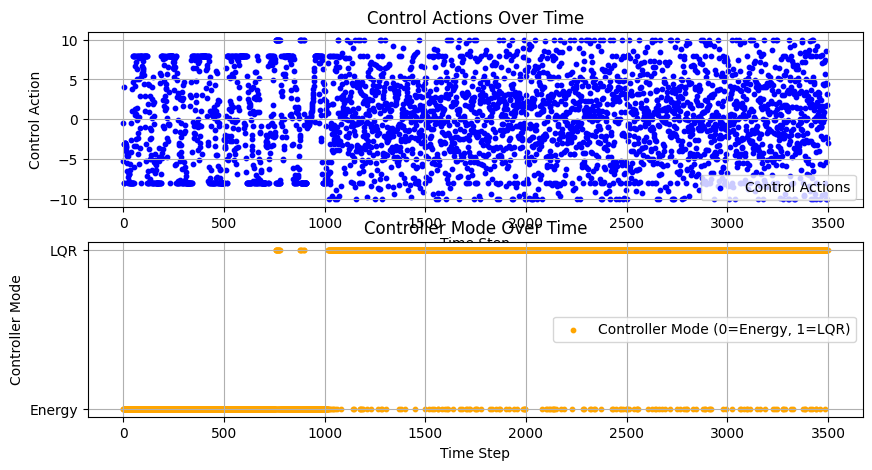

In [55]:
# y: (batch_size, num_steps, 4), control_logger: (batch_size, num_steps-1)
n = 32
print("Time steps:", t.shape)
print("States shape:", y.shape)
print("Control shape:", control_logger.shape)
print("Control modes shape:", control_modes.shape)

# Plotting
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.scatter(range(len(control_logger[n].cpu().numpy())), control_logger[n].cpu().numpy(), label='Control Actions', color='blue', s=10)
plt.title('Control Actions Over Time')
plt.xlabel('Time Step')
plt.ylabel('Control Action')
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.scatter(range(len(control_modes[n].cpu().numpy())), control_modes[n].cpu().numpy(), label='Controller Mode (0=Energy, 1=LQR)', color='orange', s=10)
plt.title('Controller Mode Over Time')
plt.xlabel('Time Step')
plt.ylabel('Controller Mode')
plt.yticks([0, 1], ['Energy', 'LQR'])
plt.grid()
plt.legend()
# plt.savefig(os.path.join(path, 'controls.png'))
# plt.close()
plt.show()

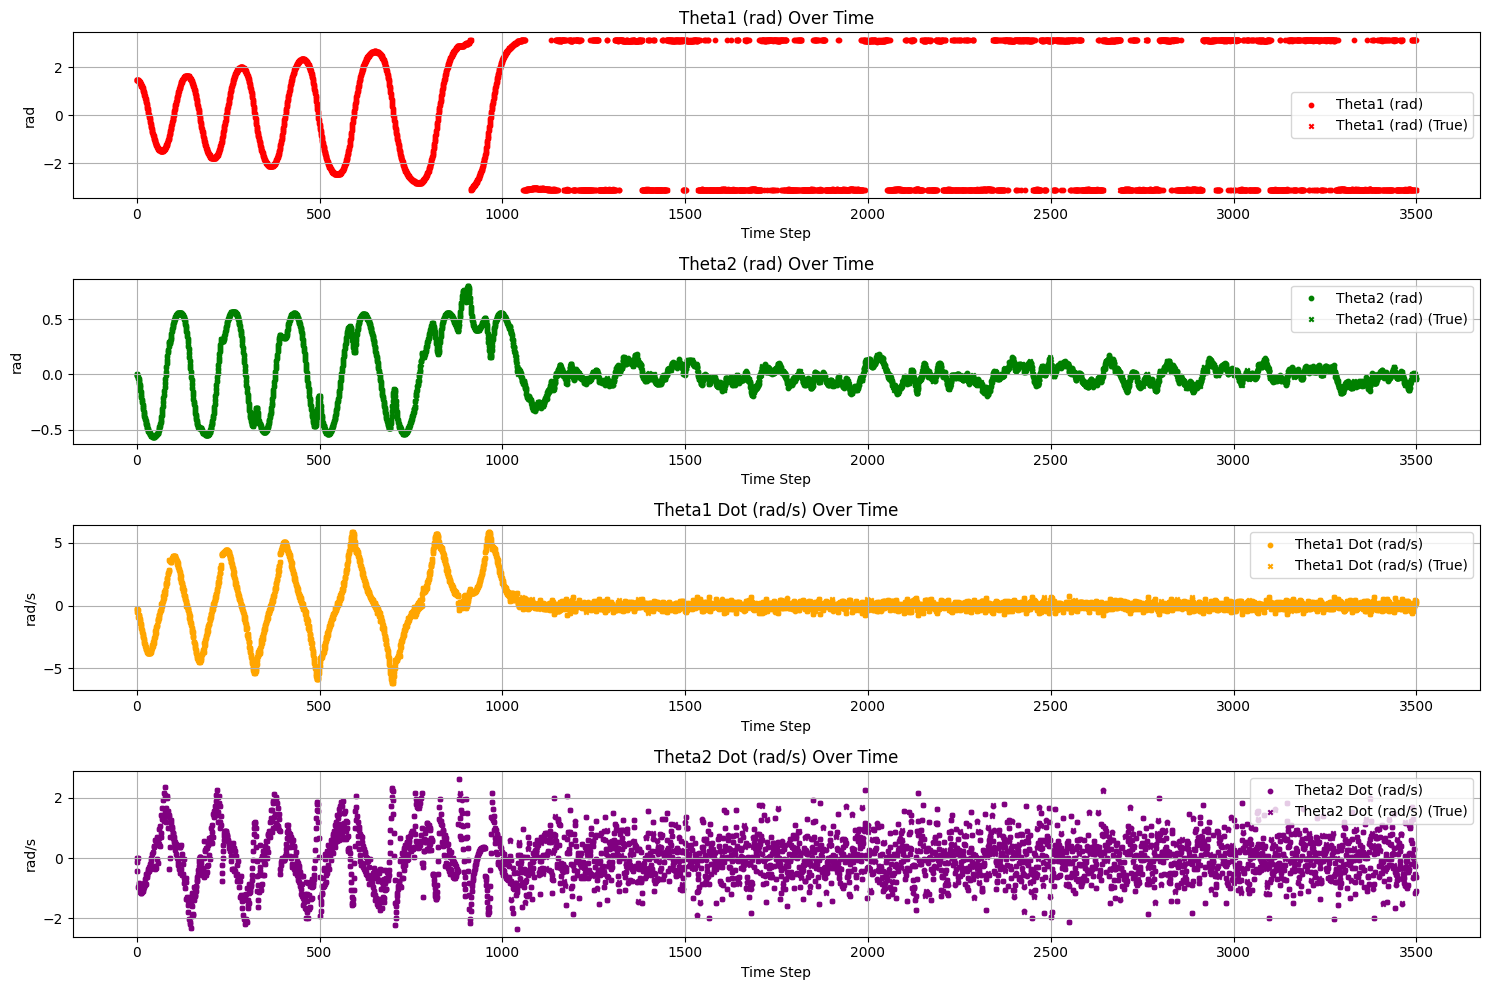

In [56]:
# Save state plots
plt.figure(figsize=(15, 10))
labels = ['Theta1 (rad)', 'Theta2 (rad)', 'Theta1 Dot (rad/s)', 'Theta2 Dot (rad/s)']
# labels = ['Cart Position (x)', 'Cart Velocity (x_dot)', 'Pole Angle (theta)', 'Pole Angular Velocity (theta_dot)']
colors = ['red', 'green', 'orange', 'purple']
for i in range(4):
    plt.subplot(4,1, i+1)
    plt.scatter(range(len(y[n].cpu().numpy())), y[n, :, i].cpu().numpy(), label=labels[i], color=colors[i], s=10)
    plt.scatter(range(len(true_y[n].cpu().numpy())), true_y[n, :, i].cpu().numpy(), label=labels[i] + ' (True)', color=colors[i], s=10, marker='x')
    plt.title(labels[i] + ' Over Time')
    plt.xlabel('Time Step')
    plt.ylabel(labels[i].split('(')[-1].rstrip(')'))
    plt.grid()
    plt.legend()
plt.tight_layout()
# plt.savefig(os.path.join(path, 'states.png'))
# plt.close()
plt.show()